# Park Task
We set up 2 actions that will differ in *yaw angle* and *required force*. \
The actions are:
- Discrete action: pull left at +5˚, Continuous kinematics: force 3g (peak)
- Discrete action: pull right at -15˚, Continuous kinematics: force 12g (peak)

We produce beta distributions from the range 1 - 15g. One bundle peaks at 3g (pull left) and another at 12g (pull right). 
We encode these distributions as 512D bundle vectors. 

Therefore, we have:
- 2 action channels: pull left vs. pull right
- Continuous action parameter (force): 3g (peak for pull left) and 12g (peak for pull right)

We create a 2x2 action grid experimental design 
|Left| Right|
|---|---|
|L @ 3g | R @ 12g|
|L @ 12g| R @ 3g|



In this case, we will have 2 discrete channels - left and right. \
Each channel will have a continous action space over the force domain [0, 15]g. \
The distribution over the left channel will have bumps/peaks at 3g and 12g. \
The distribution over the right channel will have bumps/peaks at 3g and 12g. \\

4 trials with 2 channels for left and right:
1. L3 vs. R12 - L3 is the winning channel 
2. L3 vs. R12 - R12 is the winning channel 
3. L12 vs. R3 - L12 is the winning channel 
4. L12 vs. R3 - R3 is the winning channel 

----

# Imports

In [37]:
# Add imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sspspace.sspspace.encoders import RandomSSPSpace

import nengo
from nengo.network import Network
from nengo import Node, Connection

# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility, ActionIterator, DataStorage

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create Distributions & Bundles 

In [ ]:
# ================================================
# 1. Define continuous force domain & SSP encoder
# ================================================
n_actions_park = 2
domain_force_park = np.arange(0, 15, 0.01).reshape(-1, 1) # Shape: (1500, 1)
ssp_dim_park = 512

# SSP encoder for scalar force values
ssp_encoder_park = RandomSSPSpace(
    domain_dim=1,
    ssp_dim=ssp_dim_park,
    rng=np.random.RandomState(0),
    length_scale=0.5
)
# Convert domain values to high-dimensional SSPs
domain_phis_park = ssp_encoder_park.encode(domain_force_park)  # shape: (1500, 512)
# print(domain_phis.shape)

# Place cell encoders for Nengo ensembles
low = 0
high = 15
width = high - low
places_park = np.arange(low, high, width/(domain_force_park.shape[0]))
dnf_encoders_park = np.asarray(ssp_encoder_park.encode(places_park.reshape(-1, 1))).squeeze() # Shape: (1500, 512)
# print(dnf_encoders.shape) # (512, 1500)

# ================================================
# 2. DNF Parameters
# ================================================
dnf_params_park = {
            'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions_park, 1500)], 
            'beta'            : 4,
    }


# ================================================
# 3. Generate two bundle vectors via Beta PDFs
#    Peaked at 3g and 12g respectively
# ================================================
# Beta shapes chosen so mode(a-1)/(a+b-2) matches desired peak/domain
scale = 15
# 1. Choose 4 random peak heights 
peak_heights = np.random.uniform(low=0.1, high=1.0, size=4) 
# 2. Make left and right distribution with peaks at 3 and 12
# Trick: α controls skew toward right, β toward left
# For left channel 
l3 = beta.pdf(domain_force_park, 2, 5, scale=scale) # peak at 3
l12 = beta.pdf(domain_force_park, 5, 2, scale=scale) # peak at 12
# For right channel
r3 = beta.pdf(domain_force_park, 2, 5, scale=scale) # peak at 3
r12 = beta.pdf(domain_force_park, 5, 2, scale=15) # peak at 12

distributions = [l3, l12, r3, r12]

# Combine them
# y = peak1 + peak2
# normalize > scale by saliece > combine the peaks > bundle 

# ========================================
# 4. Salience values for actions
# ========================================
# Trial 1: [L3, L12, R3, R12] - L3 wins
salience_t1 = [0.93, 0.22, 0.55, 0.61]
# Trial 2: [L3, L12, R3, R12] - L12 wins
salience_t2 = [0.25, 0.95, 0.5, 0.63]
# Trial 3: [L3, L12, R3, R12] - R3 wins
salience_t3 = [0.45, 0.62, 0.98, 0.33]
# Trial 4: [L3, L12, R3, R12] - R12 wins
salience_t4 = [0.50, 0.65, 0.40, 0.93]


# ========================================
# 5. Create bundles for the 4 sets of trials 
# ========================================
# Trial 1:
trial1 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t1, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial2 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t2, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial3 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t3, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial4 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t4, Utility.to_normalize(distributions))), domain_phis_park)
# All trials
trials = [trial1, trial2, trial3, trial4]




In [34]:
# Ensure directory exists
import os
os.makedirs('./bg_data/npz/park_bimodal/', exist_ok=True)

# Save with meaningful names
np.savez('./bg_data/npz/park_bimodal/encoders.npz', 
         ssp_encoder=ssp_encoder_park,
         dnf_encoders=dnf_encoders_park, 
         domain_phis=domain_phis_park)

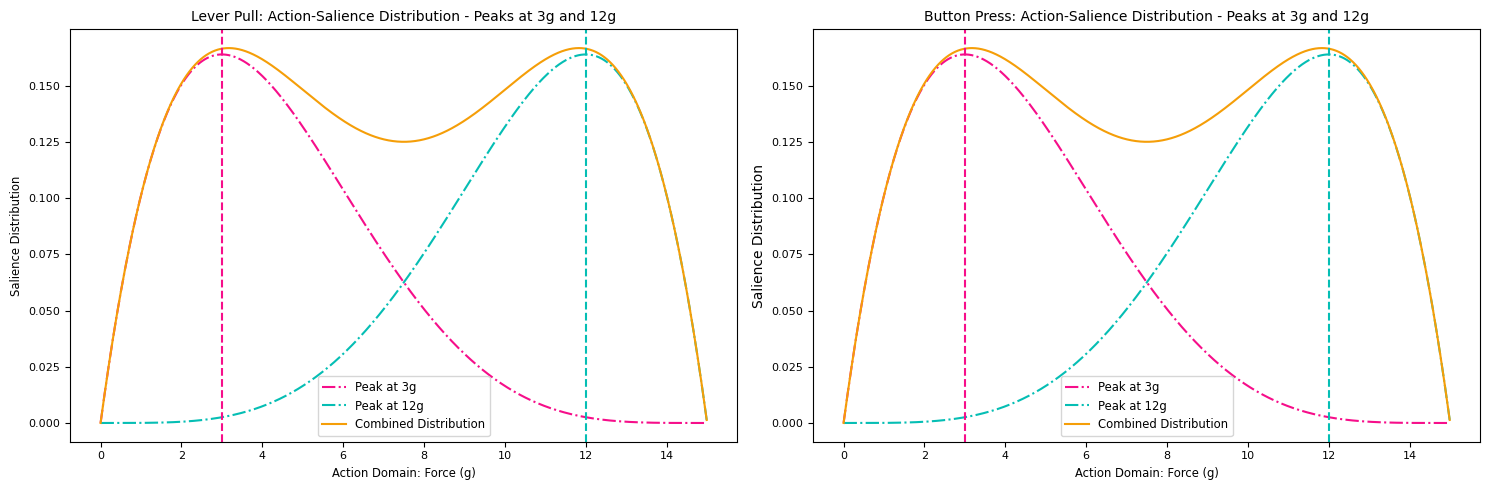

In [ ]:
# ========================================
# 6. Plot the Beta distributions for each channel
# ========================================
# Plot the left and right distributions 
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
# -------------------------------
# Plot the Left distribution 
# ---------------------------
left = l3 + l12 # combined bimodal
axes1[0].plot(domain_force_park, l3, color="#f60c89fd", linestyle='-.', label='Peak at 3g')
axes1[0].plot(domain_force_park, l12, color="#05beb4", linestyle='-.', label='Peak at 12g')
axes1[0].plot(domain_force_park, left, color="#f59e08", label='Combined Distribution')
axes1[0].axvline(x=3, linestyle='--', color="#f60c89fd")
axes1[0].axvline(x=12, linestyle='--', color="#05beb4")
axes1[0].legend(loc='best', fontsize='small')
axes1[0].set_title("Lever Pull: Action-Salience Distribution - Peaks at 3g and 12g", fontsize='medium')
axes1[0].set_xlabel("Action Domain: Force (g)", fontsize='small')
axes1[0].set_ylabel("Salience Distribution", fontsize='small')
# -------------------------------
# Plot the Right distribution 
# ---------------------------
right = r3 + r12 # combined bimodal
axes1[1].plot(domain_force_park, r3, color="#f60c89fd", linestyle='-.', label='Peak at 3g')
axes1[1].plot(domain_force_park, r12, color="#05beb4", linestyle='-.', label='Peak at 12g')
axes1[1].plot(domain_force_park, right, color="#f59e08", label='Combined Distribution')
axes1[1].axvline(x=3, linestyle='--', color="#f60c89fd")
axes1[1].axvline(x=12, linestyle='--', color="#05beb4")
axes1[1].legend(loc='best', fontsize='small')
axes1[1].set_title("Button Press: Action-Salience Distribution - Peaks at 3g and 12g", fontsize='medium')
axes1[1].set_xlabel("Action Domain: Force (g)", fontsize='small')
axes1[1].set_ylabel("Salience Distribution")

plt.tight_layout()
# plt.savefig('./figures/park/bimodal/distribution.png')
plt.savefig('./figures/park/bimodal/paper_distribution.png')
plt.show()


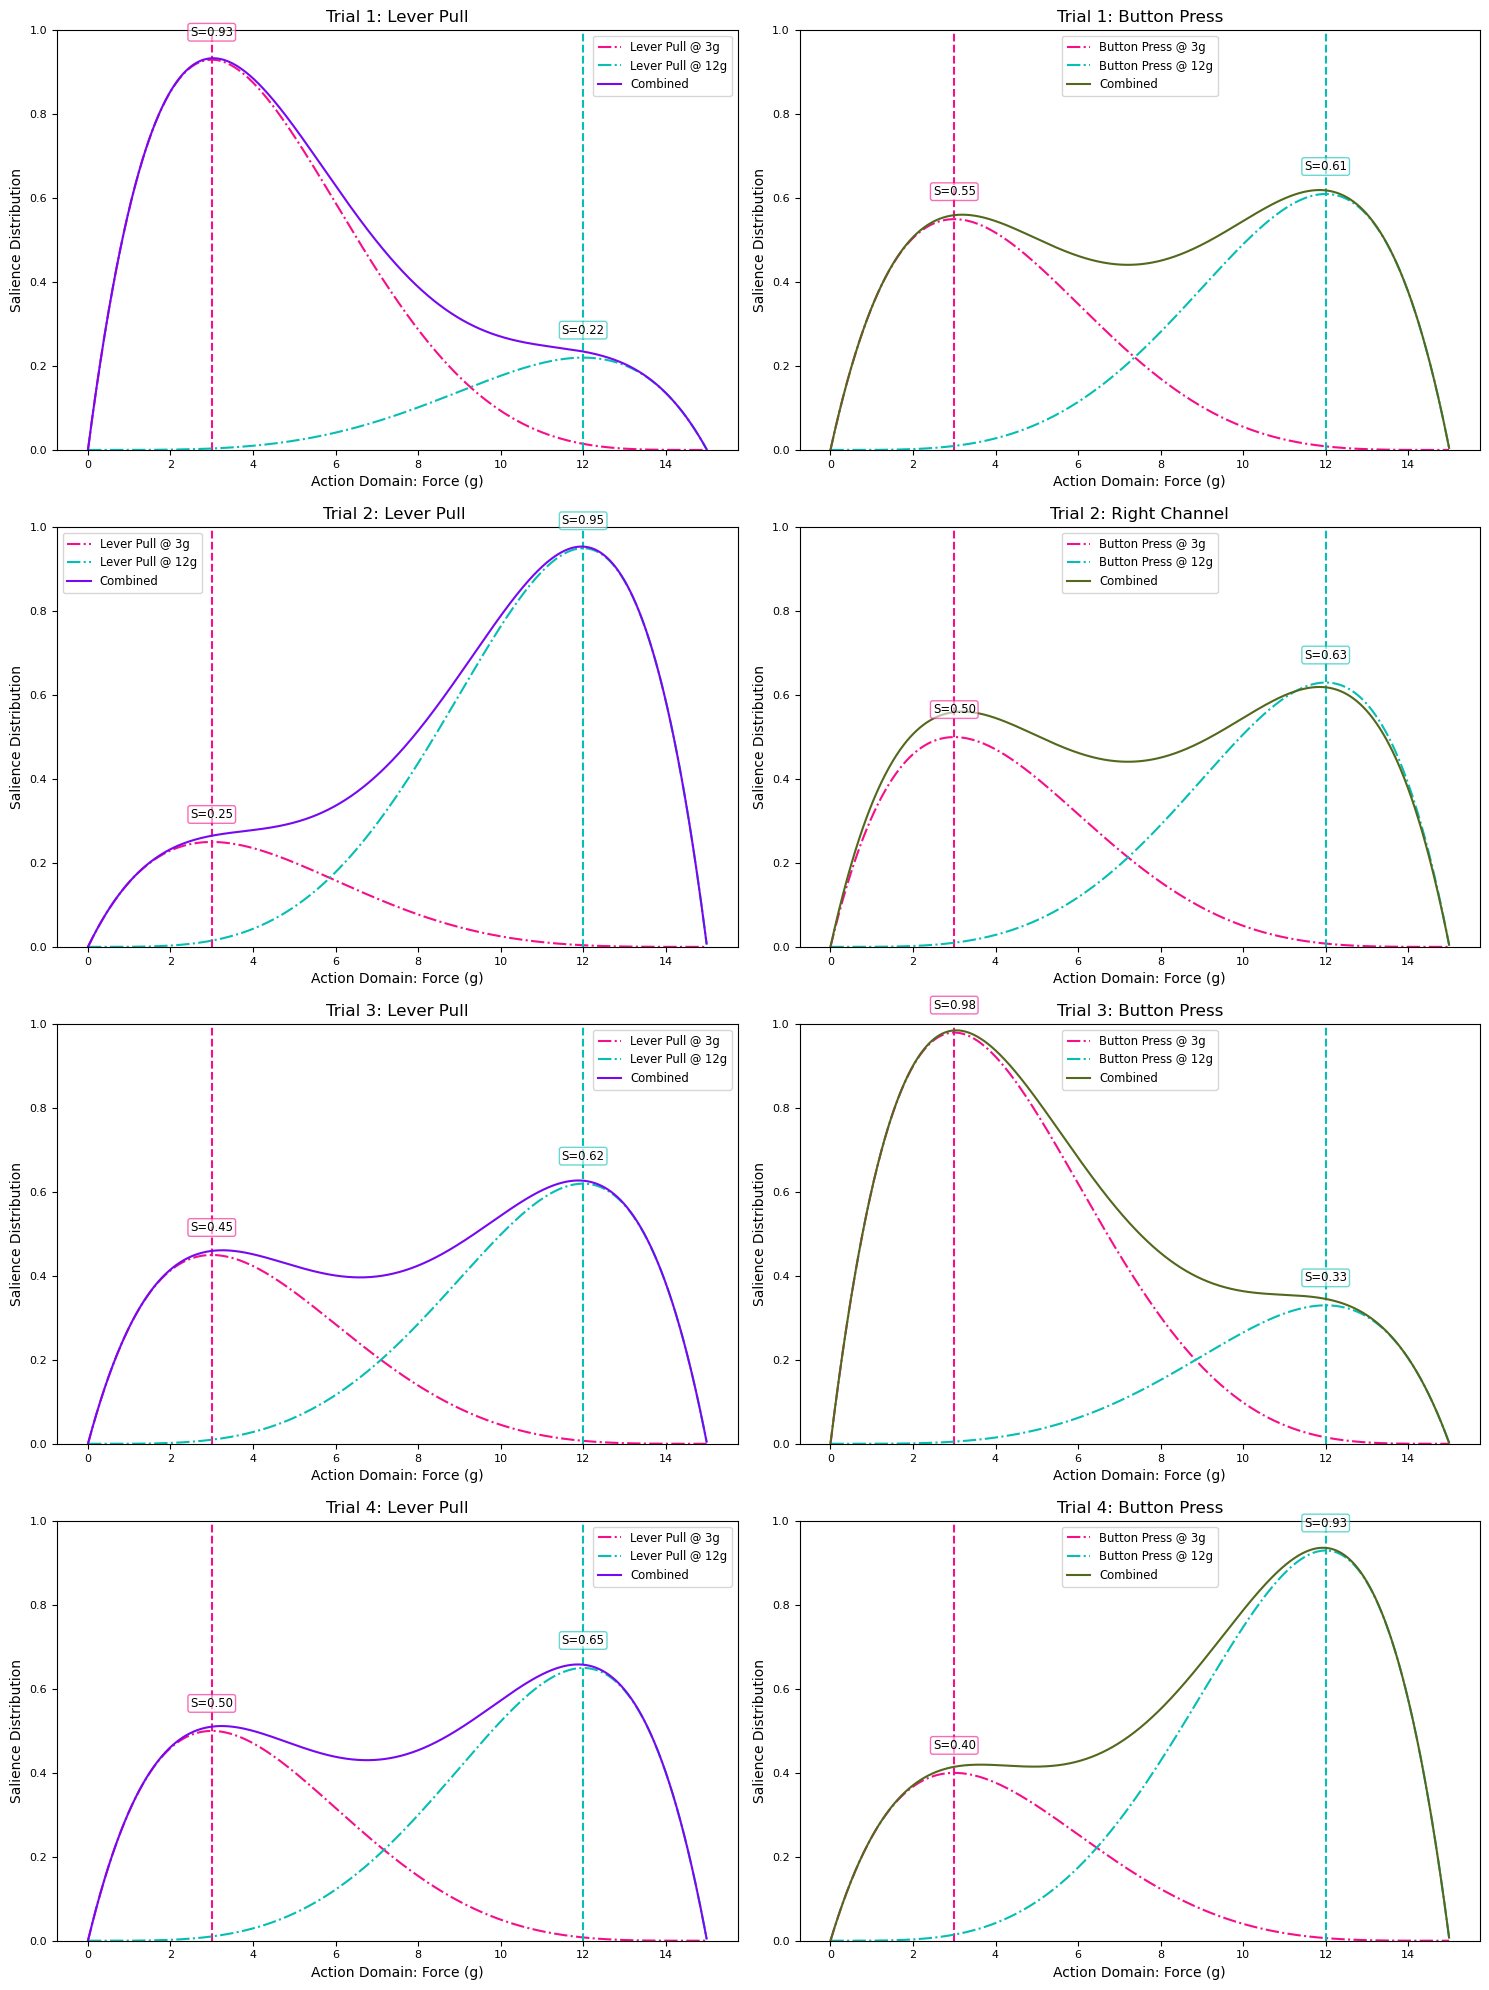

In [18]:
# ========================================
# 7. Plot the salience scaled beta distribution for each channel
# ========================================
colors = ["#f60c89fd", "#05beb4"]
actions_left = ['Lever Pull @ 3g', 'Lever Pull @ 12g']
actions_right = ['Button Press @ 3g', 'Button Press @ 12g']
peak = [3, 12]

# create 4×2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(15, 20),)

# ---------------------------------
# Trial 1: L3 vs. R12 - L3 wins!
# ---------------------------------
# (0,0): Left
t1_left = Utility.to_scale(salience=salience_t1[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left1 = t1_left[0] + t1_left[1]
for i, pdf in enumerate(t1_left):
    axes[0, 0].plot(domain_force_park, pdf, color=colors[i],
                    label=f'{actions_left[i]}', linestyle='-.')
    axes[0, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[0, 0].text(
        peak[i], salience_t1[i] + 0.05,   # place just above peak
        f"S={salience_t1[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[0, 0].plot(domain_force_park, scaled_left1, color="#7609f2", label="Combined")
axes[0, 0].set_title('Trial 1: Lever Pull', fontsize='large')
axes[0, 0].set_xlabel('Action Domain: Force (g)')
axes[0, 0].set_ylabel("Salience Distribution")
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].legend(fontsize='small')

# (0,1): Right
t1_right = Utility.to_scale(salience=salience_t1[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right1 = t1_right[0] + t1_right[1]
for j, pdf in enumerate(t1_right):
    idx = j + 2   # salience indices for right channel
    axes[0, 1].plot(domain_force_park, pdf, color=colors[j],
                    label=f'{actions_right[j]}', linestyle='-.')
    axes[0, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[0, 1].text(
        peak[j], salience_t1[idx] + 0.05,
        f"S={salience_t1[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[0, 1].plot(domain_force_park, scaled_right1, color="#52681D", label="Combined")
axes[0, 1].set_title('Trial 1: Button Press', fontsize='large')
axes[0, 1].set_xlabel('Action Domain: Force (g)')
axes[0, 1].set_ylabel('Salience Distribution')
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].legend(fontsize='small')


# ------------------------
# Trial 2: L3 vs. R12 - R12 wins!
# -----------------------
# (1, 0): Left
t2_left = Utility.to_scale(salience=salience_t2[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left2 = t2_left[0] + t2_left[1]
for i, pdf in enumerate(t2_left):
    axes[1, 0].plot(domain_force_park, pdf, color=colors[i],
                    label=f'{actions_left[i]}', linestyle='-.')
    axes[1, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[1, 0].text(
        peak[i], salience_t2[i] + 0.05,   # place just above peak
        f"S={salience_t2[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[1, 0].plot(domain_force_park, scaled_left2, color="#7609f2", label="Combined")
axes[1, 0].set_title('Trial 2: Lever Pull ', fontsize='large')
axes[1, 0].set_xlabel('Action Domain: Force (g)')
axes[1, 0].set_ylabel("Salience Distribution")
axes[1, 0].set_ylim(0, 1.0)
axes[1, 0].legend(fontsize='small')

# (1, 1): Right
t2_right = Utility.to_scale(salience=salience_t2[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right2 = t2_right[0] + t2_right[1]
for j, pdf in enumerate(t2_right):
    idx = j + 2   # salience indices for right channel
    axes[1, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[1, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[1, 1].text(
        peak[j], salience_t2[idx] + 0.05,
        f"S={salience_t2[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[1, 1].plot(domain_force_park, scaled_right1, color="#52681D", label="Combined")
axes[1, 1].set_title('Trial 2: Right Channel', fontsize='large')
axes[1, 1].set_xlabel('Action Domain: Force (g)')
axes[1, 1].set_ylabel('Salience Distribution')
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].legend(fontsize='small')

# ------------------------
# Trial 3: L12 vs. R3 - L12 wins!
# -----------------------
# (2, 0): Left
t3_left = Utility.to_scale(salience=salience_t3[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left3 = t3_left[0] + t3_left[1]
for i, pdf in enumerate(t3_left):
    axes[2, 0].plot(domain_force_park, pdf, color=colors[i], label=f'{actions_left[i]}', linestyle='-.') # type: ignore
    axes[2, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[2, 0].text(
        peak[i], salience_t3[i] + 0.05,   # place just above peak
        f"S={salience_t3[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[2, 0].plot(domain_force_park, scaled_left3, color="#7609f2", label="Combined")
axes[2, 0].set_title('Trial 3: Lever Pull', fontsize='large')
axes[2, 0].set_xlabel('Action Domain: Force (g)')
axes[2, 0].set_ylabel("Salience Distribution")
axes[2, 0].set_ylim(0, 1.0)
axes[2, 0].legend(fontsize='small')

# # (2, 1): Right
t3_right = Utility.to_scale(salience=salience_t3[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right3 = t3_right[0] + t3_right[1]
for j, pdf in enumerate(t3_right):
    idx = j + 2   # salience indices for right channel
    axes[2, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[2, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[2, 1].text(
        peak[j], salience_t3[idx] + 0.05,
        f"S={salience_t3[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[2, 1].plot(domain_force_park, scaled_right3, color="#52681D", label="Combined")
axes[2, 1].set_title('Trial 3: Button Press', fontsize='large')
axes[2, 1].set_xlabel('Action Domain: Force (g)')
axes[2, 1].set_ylabel('Salience Distribution')
axes[2, 1].set_ylim(0, 1.0)
axes[2, 1].legend(fontsize='small')

# ------------------------
# Trial 4: L12 vs. R3 - R3 wins!
# -----------------------
# (3, 0): Left
t4_left = Utility.to_scale(salience=salience_t4[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left4 = t4_left[0] + t4_left[1]
for i, pdf in enumerate(t4_left):
    axes[3, 0].plot(domain_force_park, pdf, color=colors[i], label=f'{actions_left[i]}', linestyle='-.')
    axes[3, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[3, 0].text(
        peak[i], salience_t4[i] + 0.05,   # place just above peak
        f"S={salience_t4[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[3, 0].plot(domain_force_park, scaled_left4, color="#7609f2", label="Combined")
axes[3, 0].set_title('Trial 4: Lever Pull', fontsize='large')
axes[3, 0].set_xlabel('Action Domain: Force (g)')
axes[3, 0].set_ylabel("Salience Distribution")
axes[3, 0].set_ylim(0, 1.0)
axes[3, 0].legend(fontsize='small')

# # (2, 1): Right
t4_right = Utility.to_scale(salience=salience_t4[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right4 = t4_right[0] + t4_right[1]
for j, pdf in enumerate(t4_right):
    idx = j + 2   # salience indices for right channel
    axes[3, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[3, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[3, 1].text(
        peak[j], salience_t4[idx] + 0.05,
        f"S={salience_t4[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[3, 1].plot(domain_force_park, scaled_right4, color="#52681D", label="Combined")
axes[3, 1].set_title('Trial 4: Button Press', fontsize='large')
axes[3, 1].set_xlabel('Action Domain: Force (g)')
axes[3, 1].set_ylabel('Salience Distribution')
axes[3, 1].set_ylim(0, 1.0)
axes[3, 1].legend(fontsize='small')

plt.tight_layout()
# plt.savefig('./figures/park/bimodal/trial_distribution.png')
plt.savefig('./figures/park/bimodal/paper_trial_distribution.png')
plt.show()

# Conduct Trials

In [19]:
# Run the trials and collect data 
def trial(bundles, n_actions, dnf_parameters, encoders, ssp_size = 512, d1_weight = 1.0, d2_weight = 1.0, dopamine_level = 0.2):
    assert len(bundles) == n_actions, "The number of input bundles and action channels is not the same"
    # DNF/BG Parameters
    d1_weight = d1_weight
    d2_weight = d2_weight
    dopamine_level = dopamine_level
    
    # Basal Ganglia model
    bg_model = BasalGanglia(n_actions=n_actions, dnf_parameters=dnf_parameters, encoders=encoders, dnf_neurons = 1500)
    # Add custom probes - probes input, neuron actitivies, output of gpe, gpi and stn 
    # bg_model.add_probe('gpe', index=None, what='neurons', field='input') # input to gpe
    # bg_model.add_probe('gpe', index=None, what='neurons') # neuron activities 
    # bg_model.add_probe('gpi', index=None, what='neurons', field='input') # input to gpi
    # bg_model.add_probe('gpi', index=None, what='neurons') # neuron activities 
    # bg_model.add_probe('stn', index=None, what='neurons', field='input') # input to stn
    # bg_model.add_probe('stn', index=None, what='neurons') # neuron activities 
    
    data = bg_model.simulate(input_bundles=bundles, dopamine_level=dopamine_level, presentation_time=1.5, duration=1.5)
    return data


# Run the 4 trials
run_trial1 = trial(trial1, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial2 = trial(trial2, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial3 = trial(trial3, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial4 = trial(trial4, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/nengo/neurons.py:489: RuntimeWarning: overflow encountered in exp
  output[...] = (1.0 / self.tau_ref) / (1 + np.exp(-J))


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

In [20]:
run_trial1.keys()

dict_keys(['bundle_ins', 'd1_input', 'd1_neuron', 'd2_input', 'd2_neuron', 'bundle_out', 'custom_probes'])

In [21]:
# Save trail data
# Add model data 
meta = {
    'model': 'basal_ganglia_2025_park_bimodal',
    'n_actions': 2,
    'domain': '[0, 15]',
    'domain_step': '0.01',
    'sim_time': 1.5,
    'dopamine_level': 0.2,
    'd1_weight': 1.0,
    'd2_weight': 1.0,
    'salience': {
        't1_salience': salience_t1,
        't2_salience': salience_t2,
        't3_salience': salience_t3,
        't4_salience': salience_t4,
    },
    'description': 'BG model for Park'
}

# result1 = run_trial1
run_trial1['original_distributions'] = distributions
run_trial2['original_distributions'] = distributions
run_trial3['original_distributions'] = distributions
run_trial4['original_distributions'] = distributions

# Save raw model data
ds = DataStorage(base_dir='bg_data')  # ensures ./bg_data/, ./bg_data/json, ./bg_data/npz exist

# Save both variants
# Trial 1
npz_path1 = ds.save_npz(data=run_trial1, meta=meta, run_id = 'park_bimodal/trial1')        # -> ./bg_data/npz/<run_id>.npz
json_dir1 = ds.save_json(data=run_trial1, meta=meta, run_id = 'park_bimodal/trial1')       # -> ./bg_data/json/<run_id>/
# Trial 2
npz_path2 = ds.save_npz(data=run_trial2, meta=meta, run_id = 'park_bimodal/trial2')        # -> ./bg_data/npz/<run_id>.npz
json_dir2 = ds.save_json(data=run_trial2, meta=meta, run_id = 'park_bimodal/trial2')  
# Trial 3
npz_path3 = ds.save_npz(data=run_trial3, meta=meta, run_id = 'park_bimodal/trial3')        # -> ./bg_data/npz/<run_id>.npz
json_dir3 = ds.save_json(data=run_trial3, meta=meta, run_id = 'park_bimodal/trial3')  
# Trial 4
npz_path4 = ds.save_npz(data=run_trial4, meta=meta, run_id = 'park_bimodal/trial4')        # -> ./bg_data/npz/<run_id>.npz
json_dir4 = ds.save_json(data=run_trial4, meta=meta, run_id = 'park_bimodal/trial4')  
# Load later by run_id inferred from file location:
loaded_npz, meta_npz = ds.load_npz(npz_path2)     # or ds.load_npz("<run_id>")
loaded_jsn, meta_jsn = ds.load_json(json_dir3)    # or ds.load_json("<run_id>")

# Generate Plots

## Input Bundle Plots vs. Original Beta Distributions

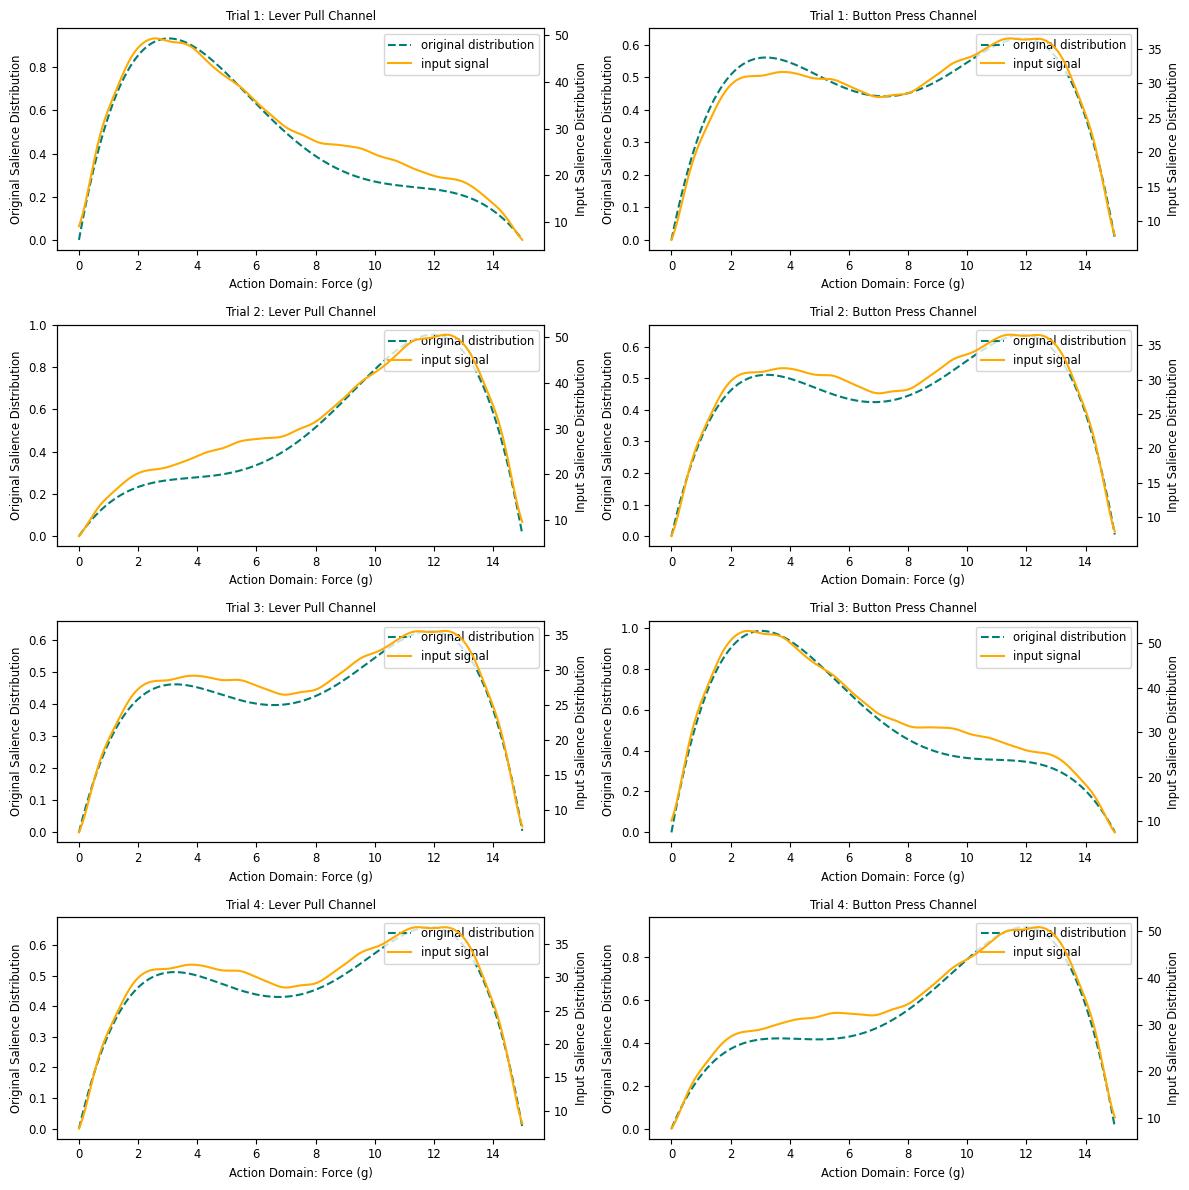

In [22]:
def plot_input_bundles(org_dist, bundle_dist, axes, trial_int, action_labels, salience_plot):
    ax = axes[trial_int]
    for i in range(n_actions_park):
        # Primary y-axis: input distribution
        ax[i].plot(domain_force_park.squeeze(), org_dist[i], ls='--', color="#007e74", label="original distribution")
        ax[i].set_xlabel("Action Domain: Force (g)", fontsize="small")
        ax[i].set_ylabel("Original Salience Distribution", fontsize="small")
        ax[i].tick_params(axis='x', labelsize='small')
        ax[i].tick_params(axis='y', labelsize='small')

        ax2 = ax[i].twinx()
        ax2.plot(domain_force_park.squeeze(), bundle_dist[i], ls='-', color="#ffaa00", label="input signal")
        ax2.set_ylabel("Input Salience Distribution", fontsize="small")
        ax2.tick_params(axis='y', labelsize='small')

        # Combined legend
        h1, l1 = ax[i].get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax[i].legend(h1 + h2, l1 + l2, loc='upper right', fontsize='small')

        ax[i].set_title(f'Trial {trial_int + 1}: {action_labels[i]} Channel', fontsize='small')


# Create a 4 x 2 grid 
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Trail 1 
bin_l_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][0][-1], domain_phis_park)
bin_r_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][1][-1], domain_phis_park)

# Trial 2
bin_l_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][0][-1], domain_phis_park)
bin_r_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][1][-1], domain_phis_park)

# Trial 3
bin_l_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][0][-1], domain_phis_park)
bin_r_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][1][-1], domain_phis_park)

# Trial 4
bin_l_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][0][-1], domain_phis_park)
bin_r_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][1][-1], domain_phis_park)

if n_actions_park == 1:
    axes = [axes]

plot_input_bundles([scaled_left1, scaled_right1], [bin_l_dist1, bin_r_dist2], axes, trial_int = 0, action_labels=['Lever Pull', 'Button Press'], salience_plot=salience_t1)
plot_input_bundles([scaled_left2, scaled_right2], [bin_l_dist2, bin_r_dist2], axes, trial_int = 1, action_labels=['Lever Pull', 'Button Press'], salience_plot=salience_t2)
plot_input_bundles([scaled_left3, scaled_right3], [bin_l_dist3, bin_r_dist3], axes, trial_int = 2, action_labels=['Lever Pull', 'Button Press'], salience_plot=salience_t3)
plot_input_bundles([scaled_left4, scaled_right4], [bin_l_dist4, bin_r_dist4], axes, trial_int = 3, action_labels=['Lever Pull', 'Button Press'], salience_plot=salience_t4)
plt.tight_layout()
plt.savefig('./figures/park/bimodal/input_bundles_park.png')
plt.savefig('./figures/park/bimodal/paper_input_bundles.png')
plt.show()




## DNF - D1 & D2

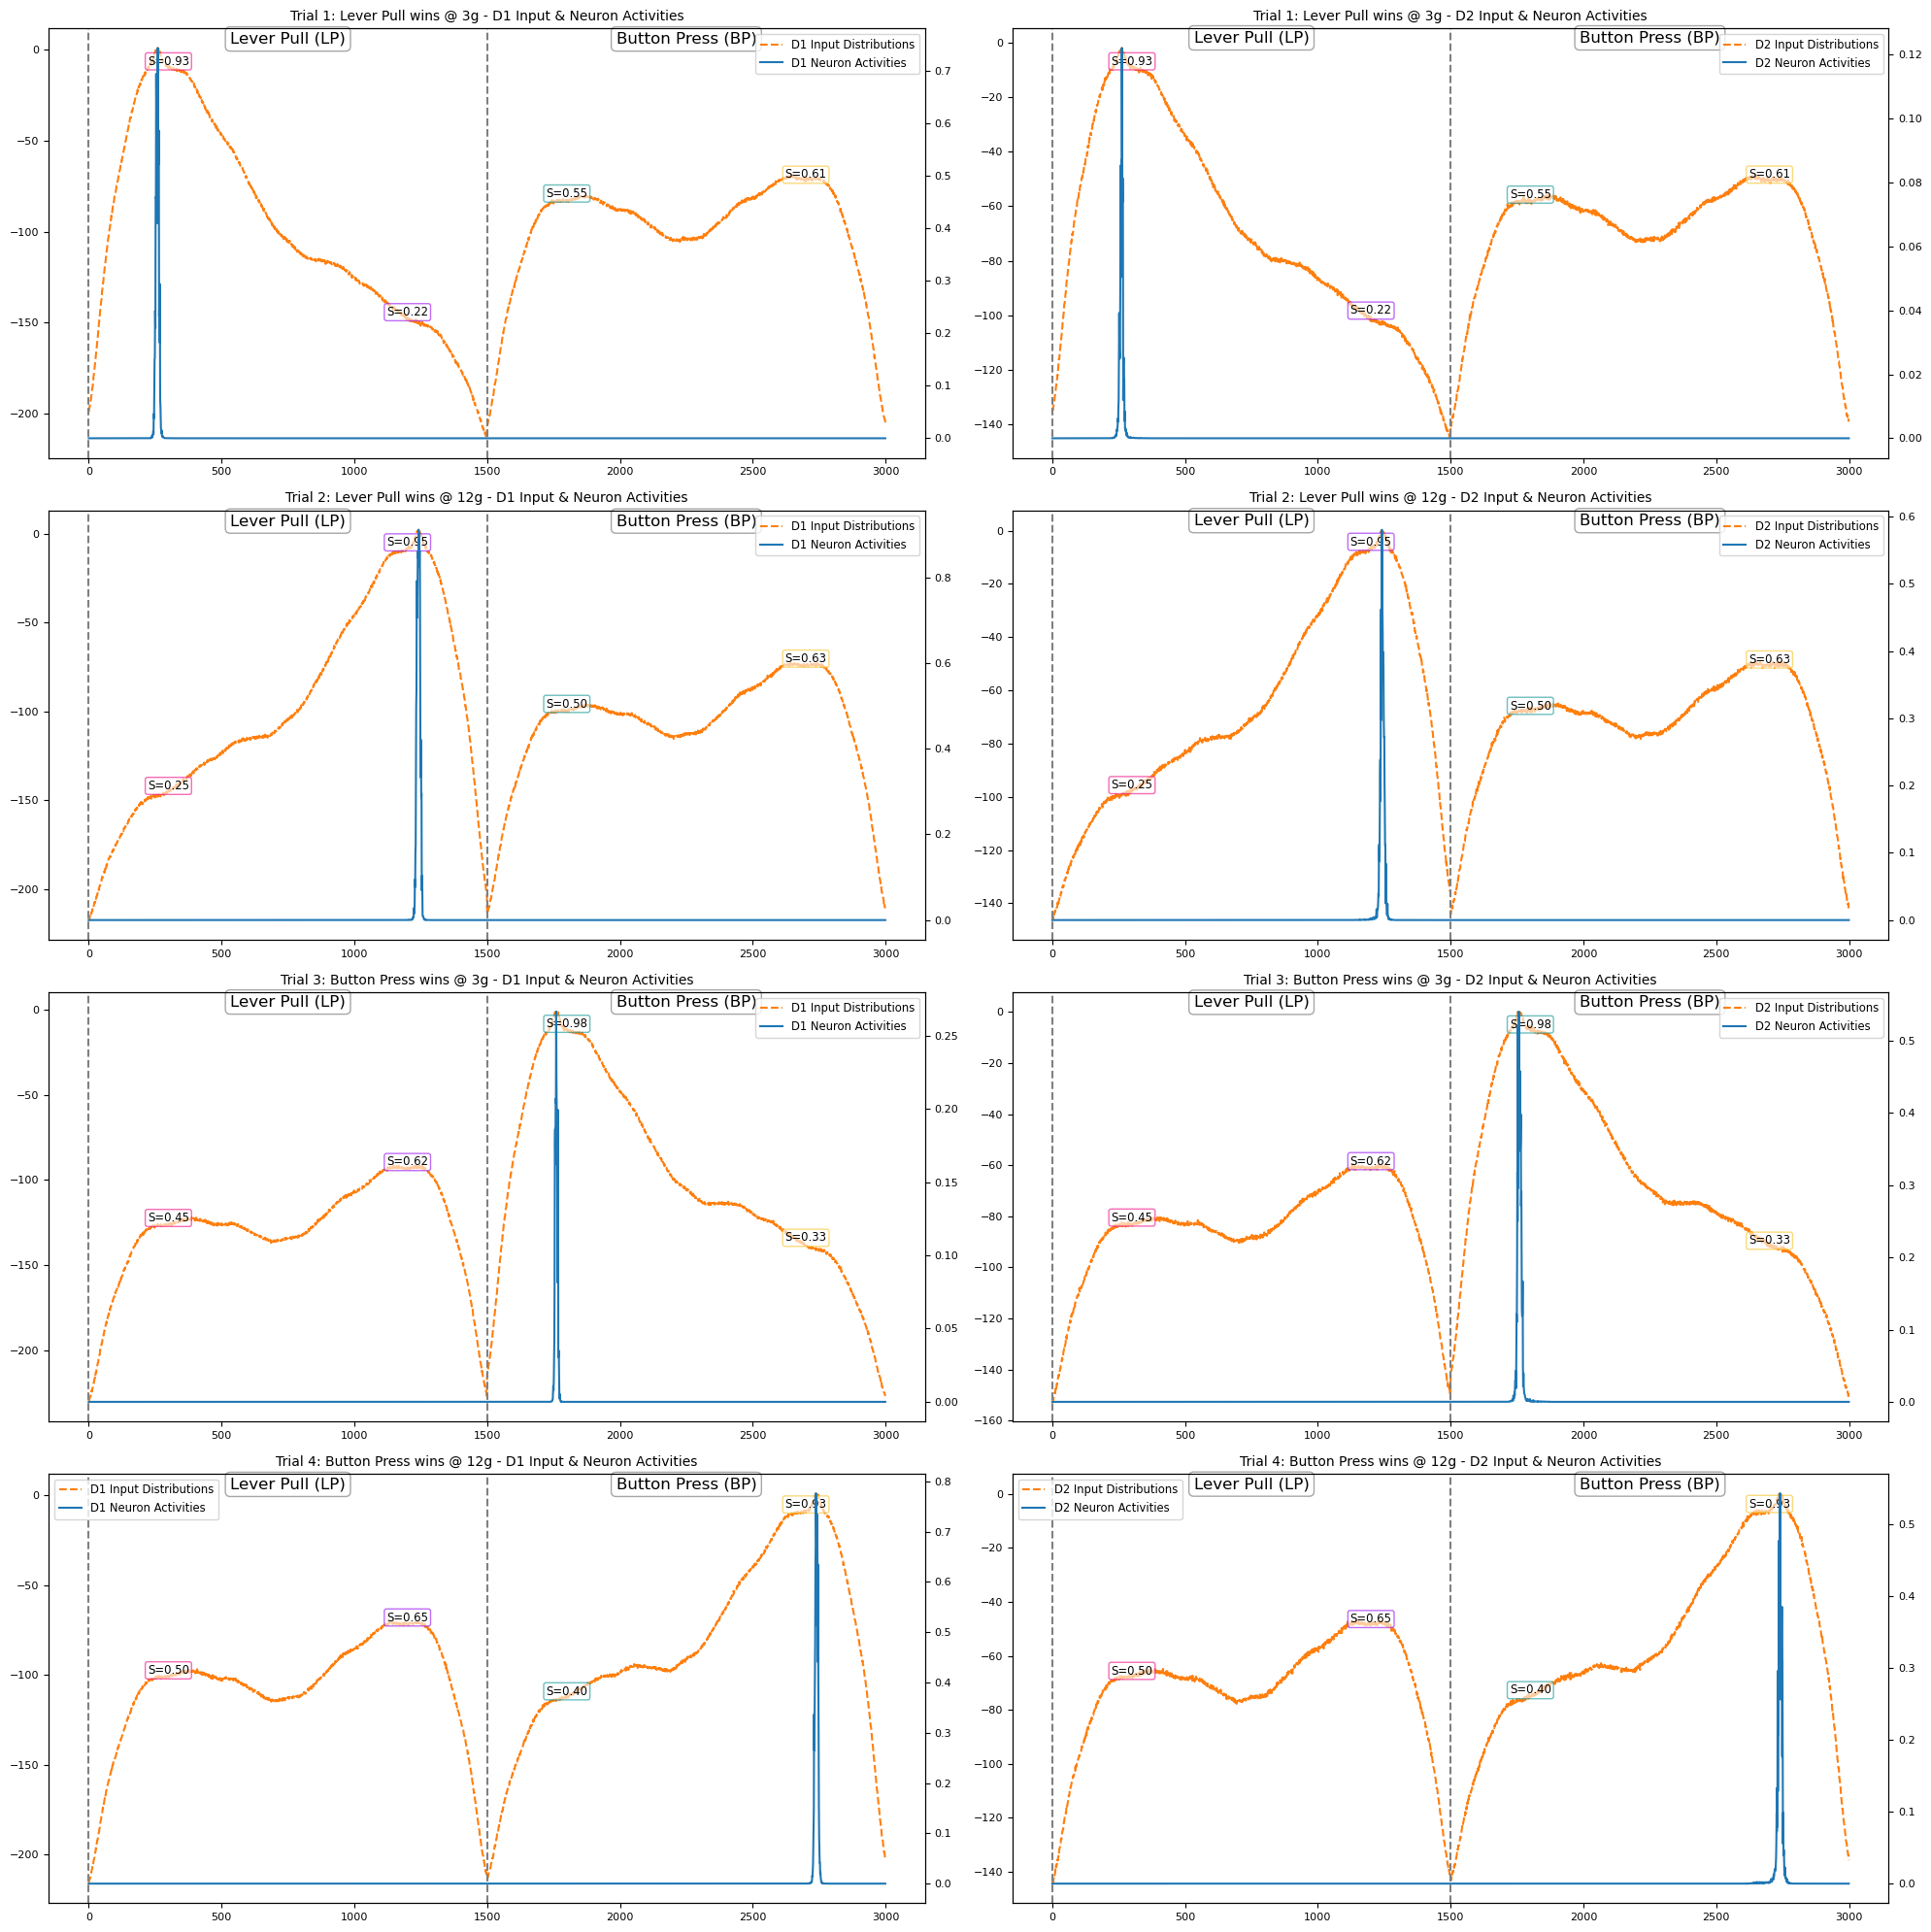

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 2, figsize=(20, 20))
trial_labels = ['Lever Pull wins @ 3g', 'Lever Pull wins @ 12g', 'Button Press wins @ 3g', 'Button Press wins @ 12g']
data_trials = [run_trial1, run_trial2, run_trial3, run_trial4]
action_labels = ['Lever Pull (LP)', 'Button Press (BP)']
peak_labels = [300, 1200, 1800, 2700]  # example peak x-positions
colors = ["#ef0a84", "#970aef", "#0d9494", "#f6c226"]
salience_labels = [salience_t1, salience_t2, salience_t3, salience_t4]

for i in range(4):  # 4 trials
    # ------------------- D1 PANEL -------------------
    axes[i, 0].plot(
        data_trials[i]['d1_input'][-1],
        label='D1 Input Distributions',
        linestyle='--', color='C1'
    )
    ax2 = axes[i, 0].twinx()
    ax2.plot(data_trials[i]['d1_neuron'][-1], label='D1 Neuron Activities')

    h1, l1 = axes[i, 0].get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    axes[i, 0].legend(h1 + h2, l1 + l2, loc='best', fontsize='small')
    axes[i, 0].set_title(f"Trial {i+1}: {trial_labels[i]} - D1 Input & Neuron Activities")

    # ------------------- D2 PANEL -------------------
    axes[i, 1].plot(
        data_trials[i]['d2_input'][-1],
        label='D2 Input Distributions',
        linestyle='--', color='C1'
    )
    ax3 = axes[i, 1].twinx()
    ax3.plot(data_trials[i]['d2_neuron'][-1], label='D2 Neuron Activities')

    h3, l3 = axes[i, 1].get_legend_handles_labels()
    h4, l4 = ax3.get_legend_handles_labels()
    axes[i, 1].legend(h3 + h4, l3 + l4, loc='best', fontsize='small')
    axes[i, 1].set_title(f"Trial {i+1}: {trial_labels[i]} - D2 Input & Neuron Activities")

    # ------------------- ADD CHANNEL LINES & LABELS -------------------
    for k in range(n_actions_park):
        xpos = k * domain_force_park.shape[0]
        axes[i, 0].axvline(xpos, linestyle='--', color='grey')
        axes[i, 1].axvline(xpos, linestyle='--', color='grey')

        if k < n_actions_park - 1:
            next_xpos = (k + 1) * domain_force_park.shape[0]
            x_text = (xpos + next_xpos) / 2
        else:
            x_text = xpos + domain_force_park.shape[0] / 2

        y_text0 = axes[i, 0].get_ylim()[1] * 0.85
        axes[i, 0].text(
            x_text, y_text0, f"{action_labels[k]}",
            ha='center', va='top', fontsize='large',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )
        y_text1 = axes[i, 1].get_ylim()[1] * 0.85
        axes[i, 1].text(
            x_text, y_text1, f"{action_labels[k]}",
            ha='center', va='top', fontsize='large',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )

    # ------------------- ADD SALIENCE LABELS -------------------
    for h, x_peak in enumerate(peak_labels):
        # D1 input axis label
        y_peak_d1 = data_trials[i]['d1_input'][-1][x_peak]
        axes[i, 0].text(
            x_peak, y_peak_d1 + 0.02,
            f"S={salience_labels[i][h]:.2f}",
            ha='center', va='bottom', fontsize='small',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[h], alpha=0.6),
            transform=axes[i, 0].transData
        )
        # D2 input axis label
        y_peak_d2 = data_trials[i]['d2_input'][-1][x_peak]
        axes[i, 1].text(
            x_peak, y_peak_d2 + 0.02,
            f"S={salience_labels[i][h]:.2f}",
            ha='center', va='bottom', fontsize='small',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[h], alpha=0.6),
            transform=axes[i, 1].transData
        )

plt.tight_layout()
plt.savefig('./figures/park/bimodal/park_dnf.png')
plt.savefig('./figures/park/bimodal/paper_dnf.png')
plt.show()


## Input vs. Output Distributions

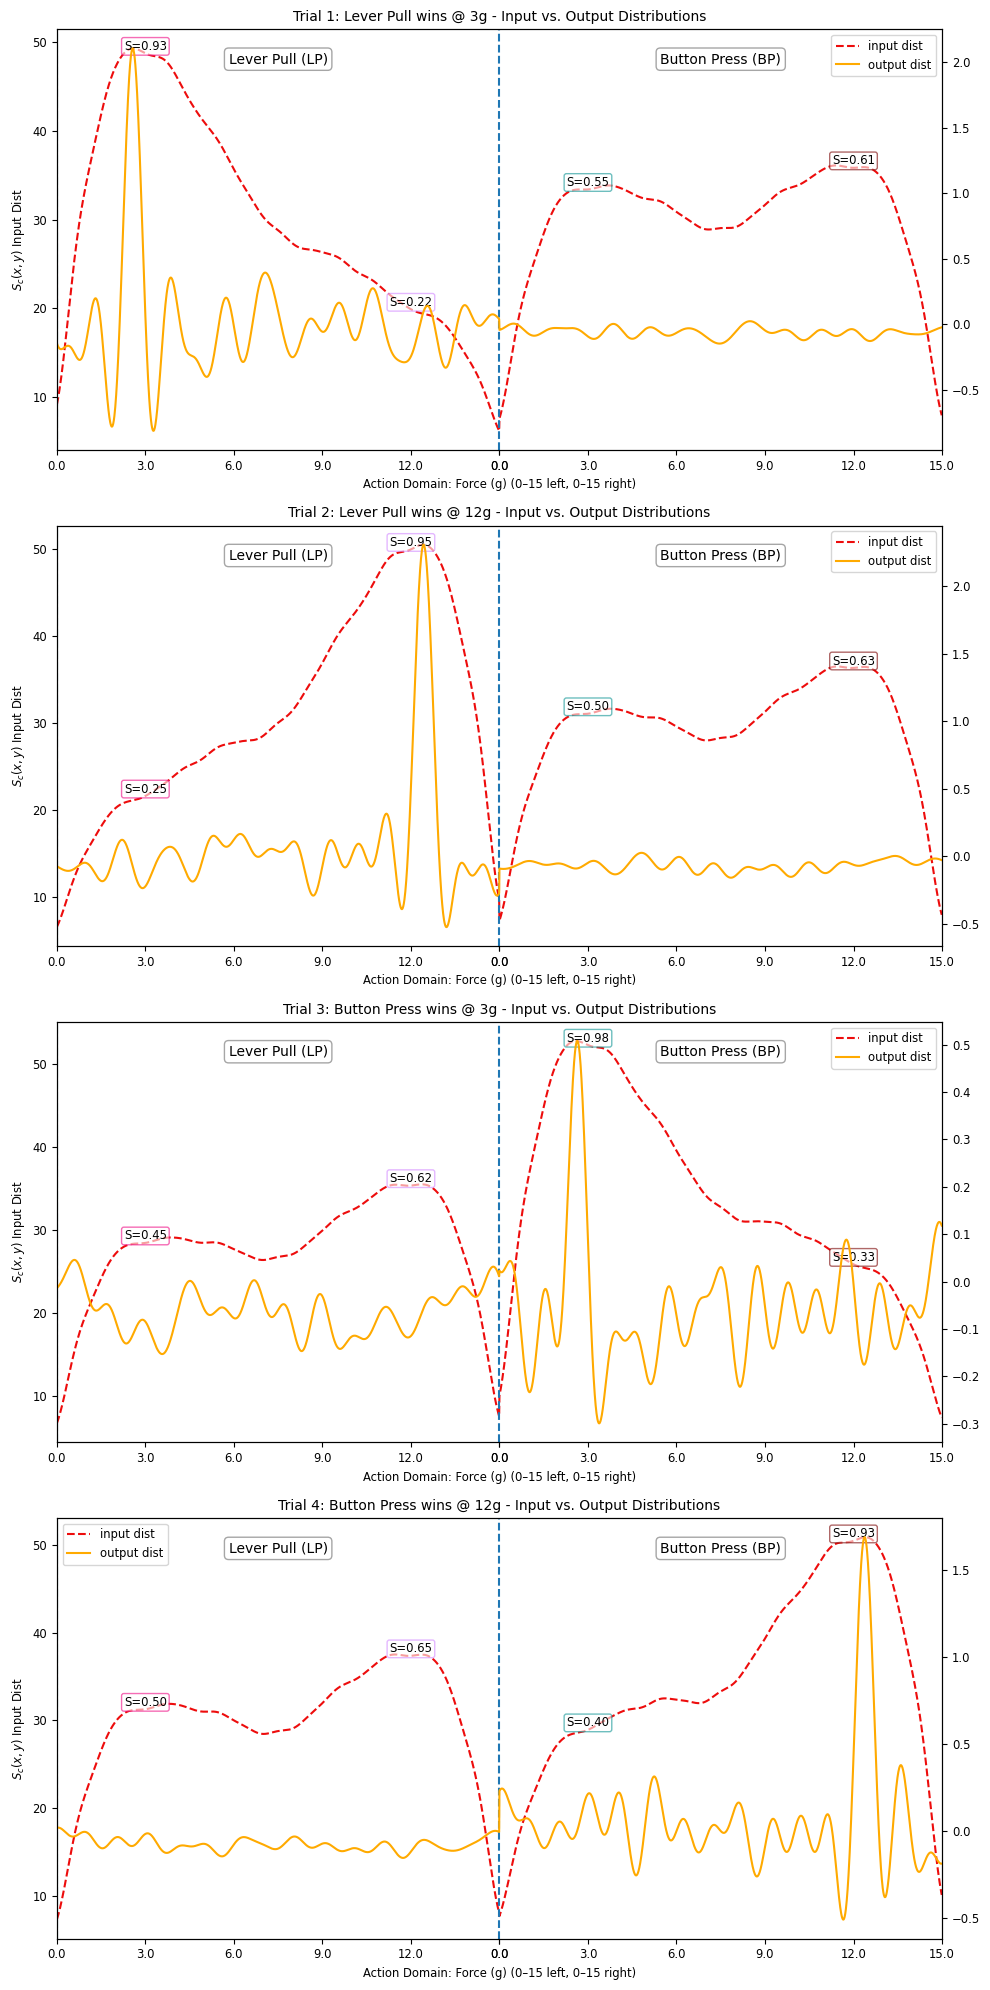

In [24]:
# trial_labels = ['L3 vs R12', 'L3 vs R12', 'L12 vs. R3', 'L12 vs. R3']
trial_labels = ['Lever Pull wins @ 3g', 'Lever Pull wins @ 12g', 'Button Press wins @ 3g', 'Button Press wins @ 12g']
data_trials = [run_trial1, run_trial2, run_trial3, run_trial4]
action_labels = ['Lever Pull (LP)', 'Button Press (BP)']
peak_labels = [300, 1200, 1800, 2700]
colors = ["#ef0a84", "#d289ff", "#0D9494", "#7a0303"]
salience_labels = [salience_t1, salience_t2, salience_t3, salience_t4]

# for each trial convert the bundle in and bundle out to distributions
# Trail 1 
bin_l3_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][0][-1], domain_phis_park)
bin_r12_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][1][-1], domain_phis_park)
bout_l3_dist1 = np.einsum('d,nd->n', run_trial1['bundle_out'][-1][0: 512], domain_phis_park)
bout_r12_dist1 = np.einsum('d,nd->n', run_trial1['bundle_out'][-1][512:], domain_phis_park)

# Trial 2
bin_l3_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][0][-1], domain_phis_park)
bin_r12_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][1][-1], domain_phis_park)
bout_l3_dist2 = np.einsum('d,nd->n', run_trial2['bundle_out'][-1][0: 512], domain_phis_park)
bout_r12_dist2 = np.einsum('d,nd->n', run_trial2['bundle_out'][-1][512:], domain_phis_park)

# Trial 3
bin_l12_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][0][-1], domain_phis_park)
bin_r3_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][1][-1], domain_phis_park)
bout_l12_dist3 = np.einsum('d,nd->n', run_trial3['bundle_out'][-1][0: 512], domain_phis_park)
bout_r3_dist3 = np.einsum('d,nd->n', run_trial3['bundle_out'][-1][512:], domain_phis_park)

# Trial 4
bin_l12_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][0][-1], domain_phis_park)
bin_r3_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][1][-1], domain_phis_park)
bout_l12_dist4 = np.einsum('d,nd->n', run_trial4['bundle_out'][-1][0: 512], domain_phis_park)
bout_r3_dist4 = np.einsum('d,nd->n', run_trial4['bundle_out'][-1][512:], domain_phis_park)

bundle_in_park = [
    np.hstack([bin_l3_dist1, bin_r12_dist1]), # Trial 1
    np.hstack([bin_l3_dist2, bin_r12_dist2]), # Trial 2
    np.hstack([bin_l12_dist3, bin_r3_dist3]), # Trial 3
    np.hstack([bin_l12_dist4, bin_r3_dist4]), # Trial 4

]

bundle_out_park = [
    np.hstack([bout_l3_dist1, bout_r12_dist1]), # Trial 1
    np.hstack([bout_l3_dist2, bout_r12_dist2]), # Trial 2
    np.hstack([bout_l12_dist3, bout_r3_dist3]), # Trial 3
    np.hstack([bout_l12_dist4, bout_r3_dist4]), # Trial 4
]

# Plot 
fig, axes = plt.subplots(4, 1, figsize=(10, 20))
plt.subplots_adjust(hspace=0.8)

if n_actions_park == 1:
    axes = [axes]

N = domain_force_park.shape[0]
d = np.arange(0, 2 * N)

ticks = np.linspace(0, N, 6).astype(int)
labels = np.linspace(0, 15, 6).round(1)
ticks2 = ticks + N

for i, ax in enumerate(axes):
    # --- Input Distribution (Left Axis) ---
    ax.plot(d, bundle_in_park[i],
            ls='--', color="#ED0C0C", label="input dist")
    ax.set_xlabel("Action Domain: Force (g) (0–15 left, 0–15 right)", fontsize="small")
    ax.set_ylabel('$S_c(x,y)$ Input Dist', fontsize='small', rotation=90,
                  labelpad=10, va='center')
    ax.tick_params(axis='x', labelsize='small')
    ax.tick_params(axis='y', labelsize='small')
    ax.set_xlim(0, 2 * N)

    # --- Custom Ticks for 0–15 left and right ---
    all_ticks = np.concatenate([ticks, ticks2])
    all_labels = [f"{lab:.1f}" for lab in labels] + [f"{lab:.1f}" for lab in labels]
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(all_labels)

    # --- Output Distribution (Right Axis) ---
    ax2 = ax.twinx()
    ax2.plot(d, bundle_out_park[i],
             ls='-', color="#ffaa00", label="output dist")
    ax2.tick_params(axis='y', labelsize='small')

    # --- Combined Legend ---
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best', fontsize='small')
    ax.set_title(f'Trial {i + 1}: {trial_labels[i]} - Input vs. Output Distributions')

    # --- Add Salience Labels Above Peaks ---
    for h, x_peak in enumerate(peak_labels):
        if x_peak < len(bundle_in_park[i]):   # guard against out-of-range
            y_peak = bundle_in_park[i][x_peak]
            ax.text(
                x_peak, y_peak + 0.05,   # just above the curve
                f"S={salience_labels[i][h]:.2f}",
                ha='center', va='bottom', fontsize='small',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[h], alpha=0.6)
            )

# --- Vertical Lines + Channel Labels ---
for i in range(4):
    for n in range(n_actions_park):
        xpos = n * N
        axes[i].axvline(xpos, linestyle='--')
        if n < n_actions_park - 1:
            next_xpos = (n + 1) * N
            x_text = (xpos + next_xpos) / 2
        else:
            x_text = xpos + N / 2
        y_text = axes[i].get_ylim()[1] * 0.95
        axes[i].text(
            x_text, y_text,
            f"{action_labels[n]}",
            ha='center', va='top',
            fontsize='medium',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )

plt.tight_layout()
plt.savefig('./figures/park/bimodal/park_output.png')
plt.savefig('./figures/park/bimodal/paper_output.png')
plt.show()




# DNF, Output Bundles - One plot Visualization

In [40]:
# Loading data
data = np.load('./bg_data/npz/park_bimodal/encoders.npz', allow_pickle=True)
ssp_encoder_park = data['ssp_encoder']
dnf_encoders_park = data['dnf_encoders']
domain_phis_park = data['domain_phis']
data.close()

# Save raw model data
ds = DataStorage(base_dir='bg_data')  # ensures ./bg_data/, ./bg_data/json, ./bg_data/npz exist
# Load data from the trials   
data_trial1, metadata_trial1 = ds.load_npz('park_bimodal/trial1')
data_trial2, metadata_trial2 = ds.load_npz('park_bimodal/trial2')
data_trial3, metadata_trial3 = ds.load_npz('park_bimodal/trial3')
data_trial4, metadata_trial4 = ds.load_npz('park_bimodal/trial4')

# DNF Neuron Activities 
trial1_dnf = data_trial1['d1_neuron'][-1] # Shape: (3000,)
trial2_dnf = data_trial2['d1_neuron'][-1]
trial3_dnf = data_trial3['d1_neuron'][-1]
trial4_dnf = data_trial4['d1_neuron'][-1]

# Output Bundles 
# Note: Re-run cell 1 to bring 'domain_phis_park' back into memory context 
trial1_lp_output = np.einsum('d,nd->n', data_trial1['bundle_out'][-1][:512], domain_phis_park) # trial 1: lever pull, shape: (1500,)
trial1_bp_output = np.einsum('d,nd->n', data_trial1['bundle_out'][-1][512:], domain_phis_park) # trial 1: button press, shape: (1500,)
trial2_lp_output = np.einsum('d,nd->n', data_trial2['bundle_out'][-1][:512], domain_phis_park) # trial 2: level pull, shape: (1500,)
trial2_bp_output = np.einsum('d,nd->n', data_trial2['bundle_out'][-1][512:], domain_phis_park) # trial 2: button press, shape: (1500,)
trial3_lp_output = np.einsum('d,nd->n', data_trial3['bundle_out'][-1][:512], domain_phis_park) # trial 3: lever pull, shape: (1500,)
trial3_bp_output = np.einsum('d,nd->n', data_trial3['bundle_out'][-1][512:], domain_phis_park) # trial 3: button press, shape: (1500,)
trial4_lp_output = np.einsum('d,nd->n', data_trial4['bundle_out'][-1][:512], domain_phis_park) # trial 4: lever pull, shape: (1500,)
trial4_bp_output = np.einsum('d,nd->n', data_trial4['bundle_out'][-1][512:], domain_phis_park) # trial 4: button press, shape: (1500,)

# Input Bundles 
# Note: Re-run cell 1 to bring 'domain_phis_park' back into memory context 
trial1_lp_input = np.einsum('d,nd->n', data_trial1['bundle_ins'][0][-1], domain_phis_park) # trial 1: lever pull, shape: (1500,)
trial1_bp_input = np.einsum('d,nd->n', data_trial1['bundle_ins'][1][-1], domain_phis_park) # trial 1: button press, shape: (1500,)
trial2_lp_input = np.einsum('d,nd->n', data_trial2['bundle_ins'][0][-1], domain_phis_park) # trial 2: level pull, shape: (1500,)
trial2_bp_input = np.einsum('d,nd->n', data_trial2['bundle_ins'][1][-1], domain_phis_park) # trial 2: button press, shape: (1500,)
trial3_lp_input = np.einsum('d,nd->n', data_trial3['bundle_ins'][0][-1], domain_phis_park) # trial 3: lever pull, shape: (1500,)
trial3_bp_input = np.einsum('d,nd->n', data_trial3['bundle_ins'][1][-1], domain_phis_park) # trial 3: button press, shape: (1500,)
trial4_lp_input = np.einsum('d,nd->n', data_trial4['bundle_ins'][0][-1], domain_phis_park) # trial 4: lever pull, shape: (1500,)
trial4_bp_input = np.einsum('d,nd->n', data_trial4['bundle_ins'][1][-1], domain_phis_park) # trial 4: button press, shape: (1500,)

trial_bundle_output = [
    np.hstack([trial1_lp_output, trial1_bp_output]), # Trial 1
    np.hstack([trial2_lp_output, trial2_bp_output]), # Trial 2
    np.hstack([trial3_lp_output, trial3_bp_output]), # Trial 3
    np.hstack([trial4_lp_output, trial4_bp_output]), # Trial 4

]

trial_bundle_input= [
    np.hstack([trial1_lp_input, trial1_bp_input]), # Trial 1
    np.hstack([trial2_lp_input, trial2_bp_input]), # Trial 2
    np.hstack([trial3_lp_input, trial3_bp_input]), # Trial 3
    np.hstack([trial4_lp_input, trial4_bp_input]), # Trial 4
]

dnf_neurons = [trial1_dnf, trial2_dnf, trial3_dnf, trial4_dnf]

# Trial Salience 
t1_salience = metadata_trial1['salience']['t1_salience']
t2_salience = metadata_trial2['salience']['t2_salience']
t3_salience = metadata_trial3['salience']['t3_salience']
t4_salience = metadata_trial4['salience']['t4_salience']
trial_saliencies_raw = [t1_salience, t2_salience, t3_salience, t4_salience]


trial_saliencies = [t1_salience, t2_salience, t3_salience, t4_salience]

# for consistent alpha scaling across trials
all_sal = np.array(trial_saliencies).ravel()
sal_min, sal_max = all_sal.min(), all_sal.max()

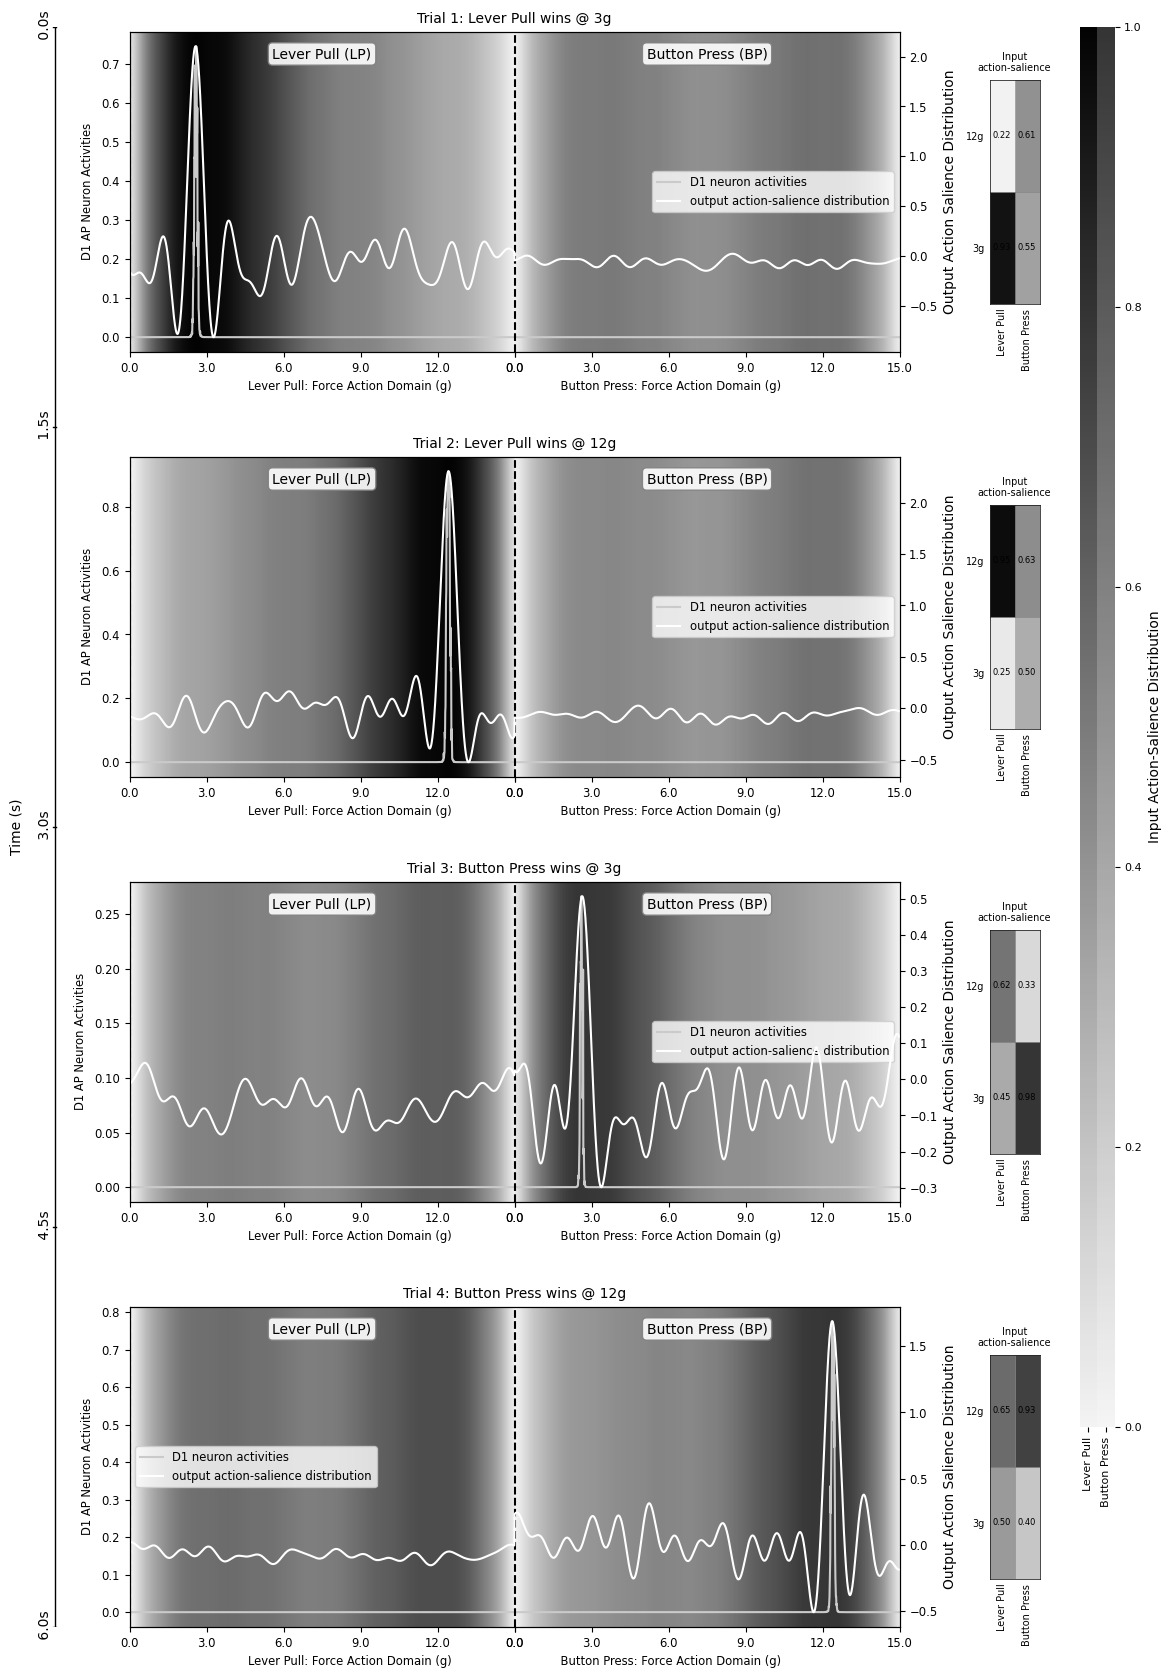

In [26]:
# Plot 
trial_labels = ['Lever Pull wins @ 3g', 'Lever Pull wins @ 12g', 'Button Press wins @ 3g', 'Button Press wins @ 12g']
action_labels = ['Lever Pull (LP)', 'Button Press (BP)']
peak_labels = [300, 1200, 1800, 2700]
n_actions_park = 2
# Time range for the global timeline
tmin, tmax = 0.0, 6.0
# Times where panel *bottoms* should sit 
panel_bottom_times = [1.5, 3.0, 4.5, 6.0]
# Full figure panel
fig = plt.figure(figsize=(10, 20))
# ======================================================
# 1. Timeline axis on the left (no box, just a line)
# ======================================================
timeline_ax = fig.add_axes([0.05, 0.05, 0.05, 0.8]) #[left, bottom, width, height]

timeline_ax.set_xlim(0, 1)
timeline_ax.set_ylim(tmin, tmax)
timeline_ax.invert_yaxis() # time increases downward

# Hide box/spines/ticks
for spine in timeline_ax.spines.values():
    spine.set_visible(False)
timeline_ax.set_xticks([])
timeline_ax.set_yticks([])
timeline_ax.patch.set_alpha(0.0)

# Draw the vertical time line 
timeline_ax.plot([0.5, 0.5], [tmin, tmax], color='black', lw=1)

# Tick marks and labels on the timeline 
for t in [0.0, 1.5, 3.0, 4.5, 6.0]:
    timeline_ax.plot([0.47, 0.53], [t, t], color='black', lw = 1) # small tick
    timeline_ax.text(0.45, t, f"{t: .1f}s", ha='right', va='center', rotation=90)
timeline_ax.set_ylabel("Time (s)")

# Arrow at the bottom to show direction of time 
timeline_ax.annotate("", xy=(0.5, tmax+0.2), xytext=(0.5, tmax), 
                     arrowprops=dict(arrowstyle="->", lw=1, color='black'))

# ======================================================
# 2. Map time -> figure bottom coordinate for panels
# ======================================================
def time_to_fig_bottom(t, tmin=tmin, tmax=tmax, margin_bottom=0.05, margin_top=0.1):
    """Map time t (tmin .. tmax) to figure 'bottom' in [0, 1]. 
    Time increases downward (0 at top, tmax at bottom)"""
    usable = 1.0 - margin_bottom - margin_top
    # t = tmin -> top (1 - margin_top); 
    # t = tmax -> bottom (margin_bottom)
    return (1.0 - margin_top) - (t - tmin)/ (tmax - tmin) * usable

panel_height = 0.16
left = 0.15
width = 0.77

axes1 = [] # left y-axis
axes2 = [] # right y-axis


# ======================================================
# 3. Create the 4 panel axes, bottoms at 1.5s / 3.0s / 4.5s / 6.0s
# ======================================================
for t in panel_bottom_times:
    bottom = time_to_fig_bottom(t)
    ax1 = fig.add_axes([left, bottom, width, panel_height])
    ax2 = ax1.twinx()
    axes1.append(ax1)
    axes2.append(ax2)

# ======================================================
# 4. Plot into each panel
# ======================================================
N = domain_force_park.shape[0] # 1500
d = np.arange(0, 2 * N)
ticks = np.linspace(0, N, 6).astype(int)
labels = np.linspace(0, 15, 6).round(1)
ticks2 = ticks + N

lp_color = np.array([0/255, 0/255, 0/255]) # yellow for Lever Pull
bp_color = np.array([50/255, 50/255, 50/255]) # pink for Button Press
dnf_color = "#CACACA"  # "#000000" '#757575' '#949494' '#CACACA'
output_color = "#FFFFFF"
alpha_min, alpha_max = 0.05, 0.99

for i, (ax1, ax2) in enumerate(zip(axes1, axes2)):
    # Left axis - DNF Neuron actitivites 
    ax1.plot(d, dnf_neurons[i], color=dnf_color, label = 'D1 neuron activities')
    ax1.set_xlabel("Lever Pull: Force Action Domain (g)" + " " * 30 + "Button Press: Force Action Domain (g)", fontsize='small')
    ax1.set_ylabel(f"D1 AP Neuron Activities", fontsize='small', rotation=90, labelpad=10, va='center')
    ax1.tick_params(axis='x', labelsize='small')
    ax1.tick_params(axis='y', labelsize='small')
    ax1.set_xlim(0, 2 * N)

    # Custom ticks for 0-15g left and right
    all_ticks = np.concatenate([ticks, ticks2])
    all_labels = [f"{lab:.1f}" for lab in labels] + [f"{lab:.1f}" for lab in labels]
    ax1.set_xticks(all_ticks)
    ax1.set_xticklabels(all_labels)

    # Output Distribution (right axis)
    ax2.plot(d, trial_bundle_output[i], color=output_color, 
             label='output action-salience distribution')
    ax2.tick_params(axis='y', labelsize='small')
    ax2.set_ylabel(f"Output Action Salience Distribution")

    # Background: input bundle via imshow
    input = trial_bundle_input[i] # shape: (2N, )
    # normalize to [0, 1]
    input_norm = (input - input.min()) / (input.max() - input.min() + 1e-9)
    # RGBA strip: height = 2pixels, width = 2N
    H, W = 2, input_norm.size
    rgba = np.zeros((H, W, 4))
    # set RGB for LP vs BP
    rgba[:, :N, :3] = lp_color
    rgba[:, N:, :3] = bp_color
    # alpha from normalized input 
    alphas = alpha_min + (alpha_max - alpha_min) * input_norm
    rgba[:, :, 3] = alphas # broadcast over the 2 rows
    # y-limits of ax1 (after plotting) so image fills the panel
    ymin, ymax = ax1.get_ylim()
    ax1.imshow(rgba, origin="lower", aspect="auto", 
               extent=[0, 2 * N, ymin, ymax],
               zorder=0, # Behind the lines
               interpolation='nearest')
    ax1.patch.set_alpha(0.0) # makes axes background transparent
    ax2.set_zorder(ax1.get_zorder() + 1) # keep ax2 lines on top

    # Combine legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='best', fontsize='small')
    ax1.set_title(f'Trial {i + 1}: {trial_labels[i]}', fontsize='medium')

    # Vertical lines + Channel Labels 
    for n in range(n_actions_park):
        xpos = n * N
        ax1.axvline(xpos, linestyle='--', color="#000000")
        if n < n_actions_park - 1:
            next_xpos = (n + 1) * N
            x_text = (xpos + next_xpos) / 2
        else:
            x_text = xpos + N/2
        y_text = ax1.get_ylim()[1] * 0.95
        ax1.text(
            x_text, y_text, 
            f"{action_labels[n]}",
            ha='center', va='top', 
            fontsize='medium', 
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9)
        )

# ======================================================
# 5. Add LP / BP gradient bars on the right
# ======================================================

# We'll show normalized input value (0–1) → shade mapping
bar_H = 256       # vertical resolution
bar_W = 2         # 2 columns: LP and BP
bar_rgba = np.zeros((bar_H, bar_W, 4))

# normalized vertical coordinate 0..1
v = np.linspace(0, 1, bar_H)
bar_alphas = alpha_min + (alpha_max - alpha_min) * v  # same mapping as panels

# column 0 = LP, column 1 = BP
bar_rgba[:, 0, :3] = lp_color
bar_rgba[:, 1, :3] = bp_color
bar_rgba[:, 0, 3] = bar_alphas
bar_rgba[:, 1, 3] = bar_alphas

# small axis on the right side of the figure
# [left, bottom, width, height] in figure coordinates
bar_ax = fig.add_axes([1.1, 0.15, 0.035, 0.7])
bar_ax.imshow(
    bar_rgba,
    origin="lower",
    aspect="auto",
    extent=[0, 2, 0, 1],   # x: [0,1]=LP, [1,2]=BP; y: normalized input
    interpolation="nearest",
)

# clean up the axis look
bar_ax.set_xticks([0.5, 1.5])
bar_ax.set_xticklabels(["Lever Pull", "Button Press"], rotation=90)
bar_ax.set_ylabel("Input Action-Salience Distribution")
bar_ax.yaxis.set_label_position("right")
bar_ax.yaxis.tick_right()

# optional: no frame around the bar
for spine in bar_ax.spines.values():
    spine.set_visible(False)

# ======================================================
# 6. Add Salience 2x2 grid 
# ======================================================
for i, s in enumerate(trial_saliencies):
    # s = [LP@3g, LP@12g, BP@3g, BP@12g]
    lp_3g, lp_12g, bp_3g, bp_12g = s

    # rows = 3g (row 0), 12g (row 1); cols = LP (0), BP (1)
    grid_vals = np.array([[lp_3g, bp_3g],
                          [lp_12g, bp_12g]])

    # normalize for alpha (global range)
    grid_norm = (grid_vals - sal_min) / (sal_max - sal_min + 1e-9)

    # Position this salience tile in figure coords:
    #   horizontally just right of main panels (left ~0.89)
    #   vertically aligned with each trial's panel bottom
    sal_left   = 1.01
    sal_width  = 0.05
    sal_bottom = time_to_fig_bottom(panel_bottom_times[i]) + panel_height * 0.15
    sal_height = panel_height * 0.7

    sal_ax = fig.add_axes([sal_left, sal_bottom, sal_width, sal_height])

    # Draw 2x2 colored tiles
    for row in range(2):        # 0: 3g, 1: 12g
        for col in range(2):    # 0: LP, 1: BP
            val   = grid_vals[row, col]
            norm  = grid_norm[row, col]
            base  = lp_color if col == 0 else bp_color
            alpha = alpha_min + (alpha_max - alpha_min) * norm

            rect = plt.Rectangle(
                (col, row), 1, 1,
                facecolor=base,
                alpha=alpha,
                edgecolor="gray",
                linewidth=0.5,
            )
            sal_ax.add_patch(rect)

            sal_ax.text(
                col + 0.5, row + 0.5,
                f"{val:.2f}",
                ha="center", va="center",
                fontsize=6,
            )

    # Configure salience tile axis
    sal_ax.set_xlim(0, 2)
    sal_ax.set_ylim(0, 2)
    sal_ax.set_xticks([0.5, 1.5])
    sal_ax.set_xticklabels(["Lever Pull", "Button Press"], fontsize=7, rotation=90)
    sal_ax.set_yticks([0.5, 1.5])
    sal_ax.set_yticklabels(["3g", "12g"], fontsize=7)
    sal_ax.tick_params(length=0)
    sal_ax.set_title("Input\naction-salience", fontsize=7)

    for spine in sal_ax.spines.values():
        spine.set_linewidth(0.5)

# plt.savefig('./figures/park/bimodal/park_output_grayscale.pdf')
# plt.savefig('./figures/park/bimodal/paper_output.png')
fig.savefig(
    "./figures/park/bimodal/park_output_grayscale.pdf",
    format="pdf",
    bbox_inches="tight",   # expands bbox to include labels/legend
    pad_inches=0.02        # small padding so nothing kisses the edge
)

plt.show()


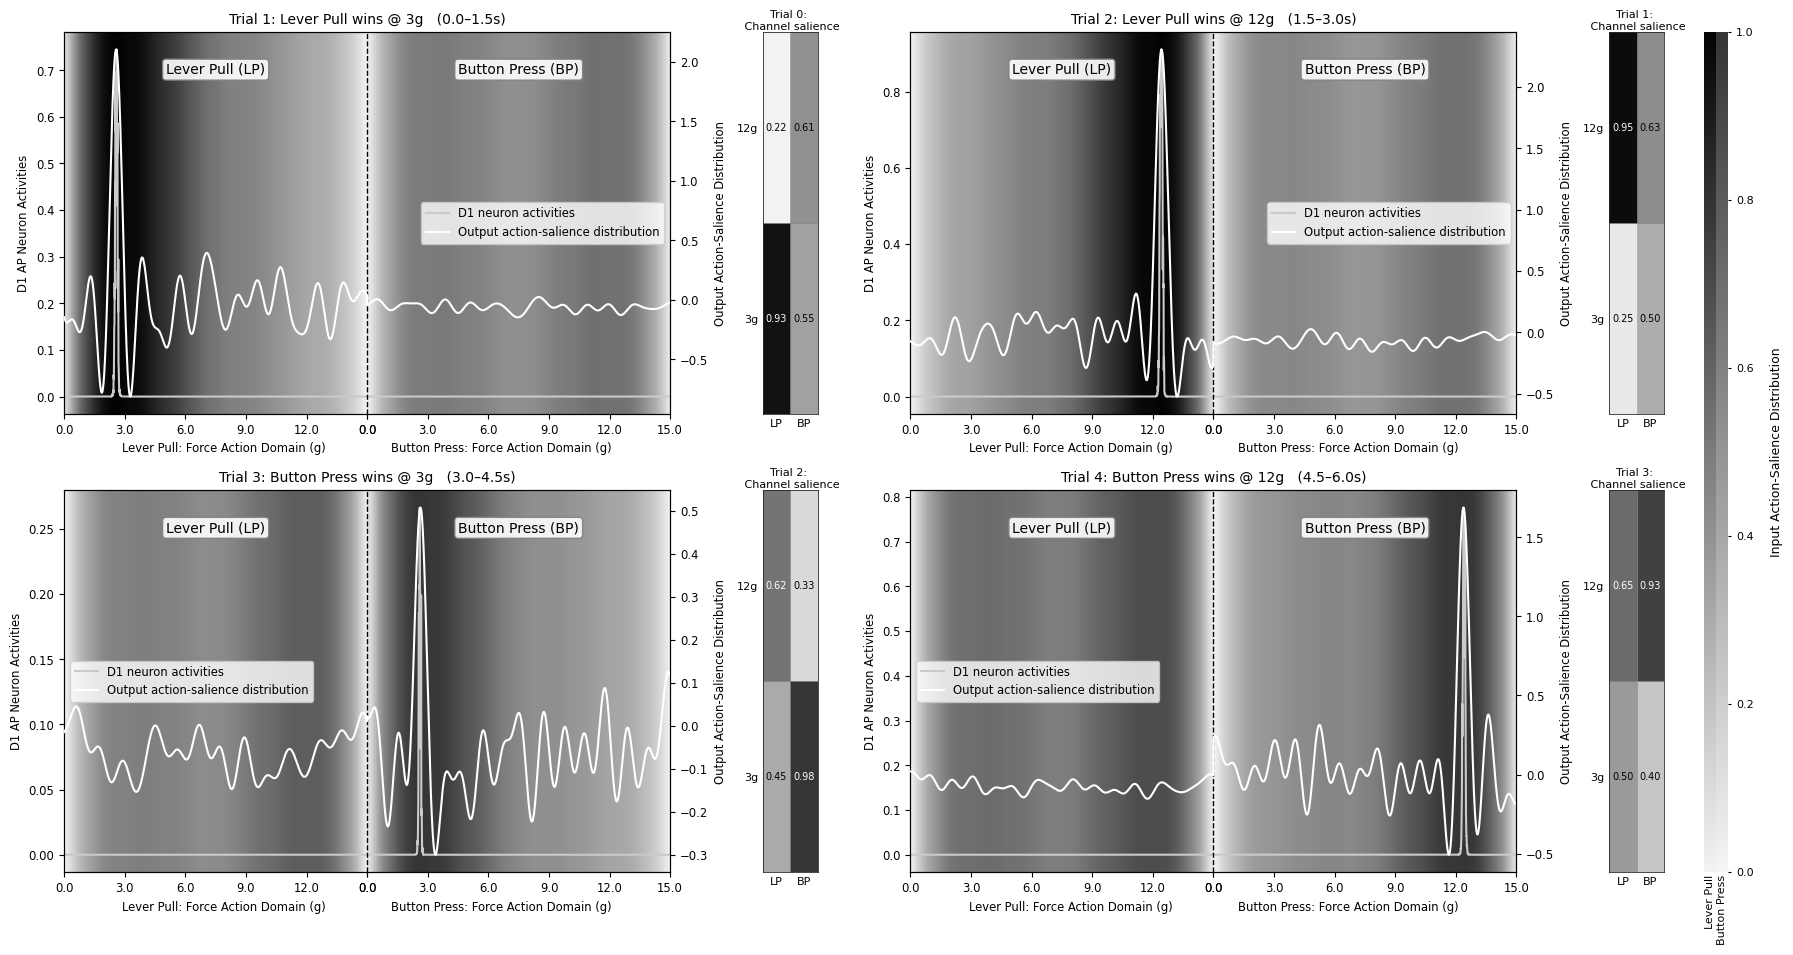

In [27]:
# Plot 2
import numpy as np
import matplotlib.pyplot as plt

def text_color_for_patch(base_rgb, alpha, bg_rgb=np.array([1.0, 1.0, 1.0]), thresh=0.55):
    """
    Choose white text if the (alpha-blended) patch looks dark on a white background.
    """
    rgb = alpha * base_rgb + (1 - alpha) * bg_rgb  # blend onto white axes bg
    lum = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]  # perceived luminance
    return "white" if lum < thresh else "black"

# ------------------------------------------------------
# Assumes these already exist (same as your current code):
#   domain_force_park      # (N,)
#   dnf_neurons            # list/array, len=4, each (2N,)
#   trial_bundle_input     # list/array, len=4, each (2N,)
#   trial_bundle_output    # list/array, len=4, each (2N,)
#   trial_saliencies       # list/array, len=4, each [LP@3g, LP@12g, BP@3g, BP@12g]
#   sal_min, sal_max       # scalars for salience normalization
# ------------------------------------------------------

# Labels
trial_labels  = ['Lever Pull wins @ 3g', 'Lever Pull wins @ 12g',
                 'Button Press wins @ 3g', 'Button Press wins @ 12g']
action_labels = ['Lever Pull (LP)', 'Button Press (BP)']
n_actions_park = 2

# Trial time windows (formerly global timeline)
panel_ends   = [1.5, 3.0, 4.5, 6.0]
panel_starts = [0.0] + panel_ends[:-1]
time_windows = list(zip(panel_starts, panel_ends))  # [(0,1.5),(1.5,3.0),(3.0,4.5),(4.5,6.0)]

# Domain/ticks
N = domain_force_park.shape[0]  # 1500
d = np.arange(0, 2 * N)

ticks  = np.linspace(0, N, 6).astype(int)
labels = np.linspace(0, 15, 6).round(1)
ticks2 = ticks + N
all_ticks  = np.concatenate([ticks, ticks2])
all_labels = [f"{lab:.1f}" for lab in labels] + [f"{lab:.1f}" for lab in labels]

# Colors
lp_color = np.array([0/255, 0/255, 0/255])
bp_color = np.array([50/255, 50/255, 50/255])
dnf_color    = "#CACACA"
output_color = "#FFFFFF"
alpha_min, alpha_max = 0.05, 0.99

# ------------------------------------------------------
# Figure layout:
# 2 rows x 2 trials, each trial has a main axis + a salience tile beside it
# (0,0)=T1, (0,1)=T2, (1,0)=T3, (1,1)=T4
# Global shade legend sits at the top-right corner.
# ------------------------------------------------------
fig = plt.figure(figsize=(20, 10))

# 2 rows, 4 columns: [trial_main, sal_tile, trial_main, sal_tile]
gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1.1, 0.10, 1.1, 0.10],
    wspace=0.28, hspace=0.20,
    left=0.06, right=0.86, top=0.92, bottom=0.08
)

main_axes = []
twin_axes = []
sal_axes  = []

# Helper: map trial index -> (row, main_col)
# Trial 1 -> (0,0), Trial 2 -> (0,2), Trial 3 -> (1,0), Trial 4 -> (1,2)
def trial_grid_pos(i):
    row = 0 if i < 2 else 1
    col = 0 if (i % 2) == 0 else 2
    return row, col

for i in range(4):
    r, c = trial_grid_pos(i)

    ax1 = fig.add_subplot(gs[r, c])
    ax2 = ax1.twinx()
    sal_ax = fig.add_subplot(gs[r, c + 1])

    main_axes.append(ax1)
    twin_axes.append(ax2)
    sal_axes.append(sal_ax)

# ------------------------------------------------------
# Plot each trial
# ------------------------------------------------------
for i, (ax1, ax2, sal_ax) in enumerate(zip(main_axes, twin_axes, sal_axes)):
    t0, t1 = time_windows[i]

    # --- Main curves ---
    ax1.plot(d, dnf_neurons[i], color=dnf_color, label="D1 neuron activities", zorder=2)
    ax2.plot(d, trial_bundle_output[i], color=output_color, label="Output action-salience distribution", zorder=3)

    # Axes formatting
    ax1.set_xlim(0, 2 * N)
    ax1.set_xticks(all_ticks)
    ax1.set_xticklabels(all_labels, fontsize="small")
    ax1.tick_params(axis="y", labelsize="small")
    ax2.tick_params(axis="y", labelsize="small")

    ax1.set_ylabel("D1 AP Neuron Activities", fontsize="small")
    ax2.set_ylabel("Output Action-Salience Distribution", fontsize="small")

    ax1.set_xlabel(
            "Lever Pull: Force Action Domain (g)" + " " * 18 + "Button Press: Force Action Domain (g)",
            fontsize="small"
        )

    # # Only label x-axis on bottom row to reduce clutter
    # if i >= 2:
    #     ax1.set_xlabel(
    #         "Lever Pull: Force Action Domain (g)" + " " * 18 + "Button Press: Force Action Domain (g)",
    #         fontsize="small"
    #     )

    # Trial title + local time window (break down the time axis per trial)
    ax1.set_title(f"Trial {i+1}: {trial_labels[i]}   ({t0:.1f}–{t1:.1f}s)", fontsize="medium")

    # --- Background strip: input bundle as shaded RGBA (LP left half, BP right half) ---
    inp = trial_bundle_input[i]  # (2N,)
    inp_norm = (inp - inp.min()) / (inp.max() - inp.min() + 1e-9)

    H, W = 2, inp_norm.size
    rgba = np.zeros((H, W, 4))
    rgba[:, :N, :3] = lp_color
    rgba[:, N:, :3] = bp_color

    alphas = alpha_min + (alpha_max - alpha_min) * inp_norm
    rgba[:, :, 3] = alphas

    ymin, ymax = ax1.get_ylim()
    ax1.imshow(
        rgba,
        origin="lower",
        aspect="auto",
        extent=[0, 2 * N, ymin, ymax],
        zorder=0,
        interpolation="nearest",
    )

    # Make sure the image stays behind the lines
    ax1.patch.set_alpha(0.0)
    ax2.set_zorder(ax1.get_zorder() + 1)

    # --- Separator + channel labels ---
    ax1.axvline(N, linestyle="--", color="#000000", lw=1, zorder=4)

    y0, y1 = ax1.get_ylim()
    y_text = y1 - 0.08 * (y1 - y0)

    ax1.text(
        N/2, y_text, action_labels[0],
        ha="center", va="top", fontsize="medium",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9),
        zorder=5
    )
    ax1.text(
        N + N/2, y_text, action_labels[1],
        ha="center", va="top", fontsize="medium",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9),
        zorder=5
    )

    # --- Legend (combined) ---
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="best", fontsize="small", frameon=True)

    # --------------------------------------------------
    # Salience tile beside each trial (2x2):
    # rows = [3g, 12g], cols = [LP, BP]
    # --------------------------------------------------
    lp_3g, lp_12g, bp_3g, bp_12g = trial_saliencies[i]
    grid_vals = np.array([[lp_3g,  bp_3g],
                        [lp_12g, bp_12g]])

    grid_norm = (grid_vals - sal_min) / (sal_max - sal_min + 1e-9)

    sal_ax.set_xlim(0, 2)
    sal_ax.set_ylim(0, 2)

    for row in range(2):
        for col in range(2):
            val   = grid_vals[row, col]
            norm  = grid_norm[row, col]
            base  = lp_color if col == 0 else bp_color
            alpha = alpha_min + (alpha_max - alpha_min) * norm

            sal_ax.add_patch(
                plt.Rectangle(
                    (col, row), 1, 1,
                    facecolor=base, alpha=alpha,
                    edgecolor="gray", linewidth=0.5
                )
            )

            tc = text_color_for_patch(base, alpha)
            sal_ax.text(
                col + 0.5, row + 0.5,
                f"{val:.2f}",
                ha="center", va="center",   # keep horizontal + centered
                fontsize=7,
                color=tc
            )

    sal_ax.set_xticks([0.5, 1.5])
    sal_ax.set_xticklabels(["LP", "BP"], fontsize=8)
    sal_ax.set_yticks([0.5, 1.5])
    sal_ax.set_yticklabels(["3g", "12g"], fontsize=8)
    sal_ax.tick_params(length=0)

    for t in range(4):
        sal_ax.set_title(f"Trial {i}: \n Channel salience", fontsize=8, pad=2)

    for spine in sal_ax.spines.values():
        spine.set_linewidth(0.5)


# ------------------------------------------------------
# Global shade legend at the top-right corner (LP vs BP alpha mapping)
# ------------------------------------------------------
# ------------------------------------------------------
# Full-height shade legend on the far right (LP vs BP α mapping)
# ------------------------------------------------------
bar_H = 500
bar_rgba = np.zeros((bar_H, 2, 4))   # <-- 2 columns: LP, BP

v = np.linspace(0, 1, bar_H)
bar_alphas = alpha_min + (alpha_max - alpha_min) * v

# RGB
bar_rgba[:, 0, :3] = lp_color
bar_rgba[:, 1, :3] = bp_color
# Alpha
bar_rgba[:, 0, 3]  = bar_alphas
bar_rgba[:, 1, 3]  = bar_alphas

# Place as a tall strip along the right side (figure coords)
# Adjust bottom/height to match your layout margins
bar_left   = 0.88  # push to the far right
bar_bottom = 0.08
bar_width  = 0.012
bar_height = 0.84   # spans almost entire figure height

bar_ax = fig.add_axes([bar_left, bar_bottom, bar_width, bar_height])
bar_ax.imshow(
    bar_rgba,
    origin="lower",
    aspect="auto",
    extent=[0, 2, 0, 1],     # x: [0,1]=LP, [1,2]=BP ; y: low->high
    interpolation="nearest",
)

# Bottom labels
bar_ax.set_xticks([0.5, 1.5])
bar_ax.set_xticklabels(["Lever Pull", "Button Press"], rotation=90, fontsize=8)

# Right-side ticks + label
bar_ax.set_yticks(np.linspace(0, 1, 6))
bar_ax.set_yticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)], fontsize=8)
bar_ax.yaxis.tick_right()
bar_ax.yaxis.set_label_position("right")
bar_ax.set_ylabel("Input Action-Salience Distribution", rotation=90, labelpad=12, fontsize=9)

# Clean look
bar_ax.tick_params(axis="x", length=0, pad=2)
bar_ax.tick_params(axis="y", length=2)
for spine in bar_ax.spines.values():
    spine.set_visible(False)


# ------------------------------------------------------
# Save
# ------------------------------------------------------
fig.savefig(
    "./figures/park/bimodal/park_output_grayscale_2x2.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()


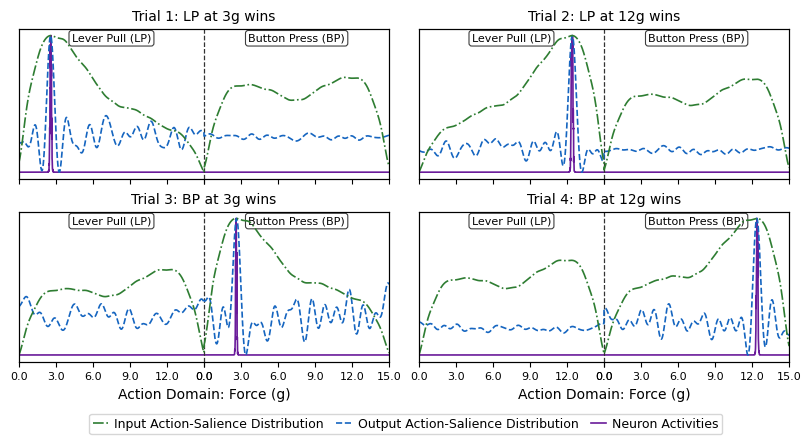

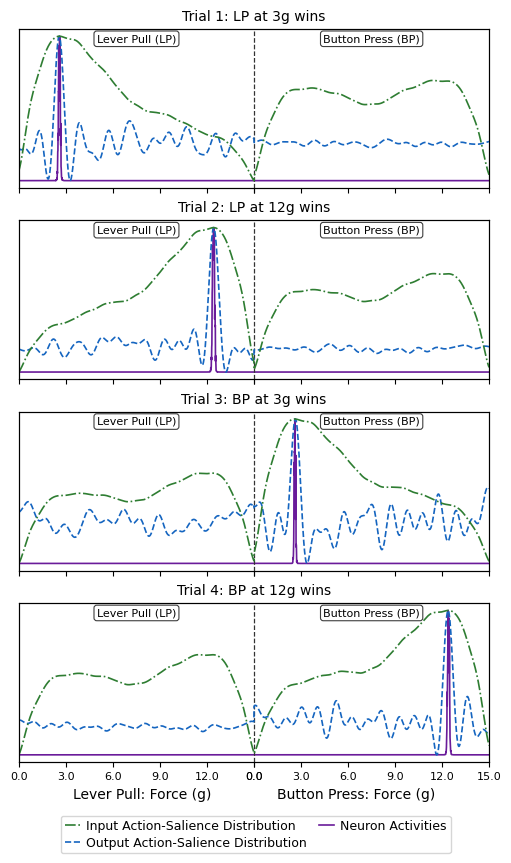

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Domain ticks
# =======================
N = domain_force_park.shape[0]  # 1500
d = np.arange(0, 2 * N)

ticks  = np.linspace(0, N, 6).astype(int)
labels = np.linspace(0, 15, 6).round(1)
ticks2 = ticks + N
all_ticks  = np.concatenate([ticks, ticks2])
all_labels = [f"{lab:.1f}" for lab in labels] + [f"{lab:.1f}" for lab in labels]

# =======================
# Scaling
# ========================
def scale_to_match(source, target):
    # map source linearly to min/max equal target 
    s_min, s_max = source.min(), source.max()
    t_min, t_max = target.min(), target.max()
    return (source - s_min) * (t_max - t_min)/ (s_max - s_min) + t_min

# ============================
# Styles
# ============================
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# COL_INP = "0.55"   # grayscale
# COL_OUT = "0.35"
# COL_DNF = "0.05"

COL_INP = "#2e7d32" # dark green (dashed)
COL_OUT = "#1565c0" # dark blue 
COL_DNF = "#6a1b9a" # dark purple
LS_DNF, LS_OUT, LS_INP = "-", "--", "-."

def plot_trial_panel(ax, trial_idx, title, show_legend=False, two = True):
    inp = trial_bundle_input[trial_idx]
    out = trial_bundle_output[trial_idx]
    neu = dnf_neurons[trial_idx]

    # sanity checks (catch silent shape mismatches)
    assert inp.shape[0] == 2*N, f"input len {inp.shape[0]} != 2N={2*N}"
    assert out.shape[0] == 2*N, f"output len {out.shape[0]} != 2N={2*N}"
    assert neu.shape[0] == 2*N, f"dnf len {neu.shape[0]} != 2N={2*N}"

    # Primary axis: DNF
    l_dnf, = ax.plot(d, neu, color=COL_DNF, ls=LS_DNF, lw=1.2, label="Neuron Activities")
    # ax.set_ylabel('DNF Neuron Activities', fontsize=8)

    # Secondary axis: Input + Output
    ax2 = ax.twinx()
    scaled_input = scale_to_match(source=inp, target=out)
    l_out, = ax2.plot(d, out, color=COL_OUT, ls=LS_OUT, lw=1.2, label="Output Action-Salience Distribution")
    l_inp, = ax2.plot(d, scaled_input, color=COL_INP, ls=LS_INP, lw=1.2, label="Input Action-Salience Distribution")
    # ax2.set_ylabel('Input & Output \n Action-Salience Distribution', fontsize=8)

    # Split marker
    ax.axvline(N, color="0.2", ls="--", lw=0.9)

    # ticks/labels
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(all_labels)
    ax.set_xlim(0, 2*N)
    if two and (trial_idx == 2 or trial_idx == 3):
        ax.set_xlabel("Action Domain: Force (g)")
    if not two and (trial_idx == 3): 
        ax.set_xlabel("Lever Pull: Force (g)" + " " * 15 + "Button Press: Force (g)")

    ax.set_title(title)


    # hide all y-axis ticks and labels
    ax.tick_params(axis="y", which="both", left=False, labelleft=False)
    ax2.tick_params(axis="y", which="both", right=False, labelright=False)
    # if trial_idx == 0 or trial_idx == 2:
    #     ax.tick_params(axis="y", which="both", labelleft=True)
    # if trial_idx == 1 or trial_idx == 3:
    #     ax2.tick_params(axis="y", which="both", labelright=True)

    if show_legend:
        ax.legend(handles=[l_inp, l_out, l_dnf], fontsize=9, framealpha=0.92, loc="upper center")
    
    # -------------------------
    # Channel labels (LP / BP)
    # -------------------------
    box = dict(boxstyle="round,pad=0.25", fc="white", ec="0.2", lw=0.8, alpha=0.95)

    # x positions are in axes fraction: 0.25 = middle of left half, 0.75 = middle of right half
    ax.text(0.25, 0.97, "Lever Pull (LP)",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=8, bbox=box, zorder=10)

    ax.text(0.75, 0.97, "Button Press (BP)",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=8, bbox=box, zorder=10)

    # Return legend handles from THIS axis (important: twin axis lines won't show unless we return them)
    return [l_inp, l_out, l_dnf]

def add_bottom_legend(fig, handles, labels, ncol=3):
    """
    Compact, paper-friendly legend at the bottom that won't cover x-labels.
    """
    # Reserve space at the bottom for the legend
    fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.005),  # outside
        ncol=ncol,
        frameon=True,
        fontsize=9,
        handlelength=1.2,
        handletextpad=0.5,
        columnspacing=1.0,
        borderpad=0.3,
        labelspacing=0.3,
    )

# ===================
# Figure: 2x2
# ===================
figshape = (8, 4)
fig, axes = plt.subplots(2, 2, figsize=figshape, sharex=True, constrained_layout=True)
axs = axes.ravel()

titles = [
    "Trial 1: LP at 3g wins",
    "Trial 2: LP at 12g wins",
    "Trial 3: BP at 3g wins",
    "Trial 4: BP at 12g wins",
]
legend_handles = None
for i, ax in enumerate(axs):
    handles = plot_trial_panel(ax, i, titles[i], two=True)
    if legend_handles is None:
        legend_handles = handles  # grab once (identical across panels)

legend_labels = [h.get_label() for h in legend_handles]
add_bottom_legend(fig, legend_handles, legend_labels, ncol=3)
fig.savefig(
    "./figures/park/bimodal/final_result_2x2.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)
plt.show()

# ===================
# Figure: 4 x1 
# ===================
figshape = (5, 8)
fig, axes = plt.subplots(4, 1, figsize=figshape, sharex=True, constrained_layout=True)
axs = axes.ravel()

titles = [
    "Trial 1: LP at 3g wins",
    "Trial 2: LP at 12g wins",
    "Trial 3: BP at 3g wins",
    "Trial 4: BP at 12g wins",
]

legend_handles = None
for i, ax in enumerate(axs):
    handles = plot_trial_panel(ax, i, titles[i], two=False)
    if legend_handles is None:
        legend_handles = handles

legend_labels = [h.get_label() for h in legend_handles]
add_bottom_legend(fig, legend_handles, legend_labels, ncol=2)
fig.savefig(
    "./figures/park/bimodal/final_result_4x1.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)
plt.show()
